# NACA 0012 — Multi-AoA Sweep (GPU Parallel, Google Colab T4)

Runs **all angles of attack simultaneously** in a single batched GPU pass.
Every field has shape `(n_aoa, Ny, Nx)` — one GPU kernel advances all AoA at once.

| Parameter | Value |
|-----------|-------|
| Airfoil   | NACA 0012 |
| Re        | 100 |
| AoA values | 0°, 5°, 10°, 15°, 20° |
| Grid      | 220 × 100 |
| Time steps | 20 000 |
| Algorithm | Fractional-step (upwind convection + Jacobi Poisson) |
| Backend   | CuPy (GPU) — falls back to NumPy if no GPU found |

## 1  Colab GPU Setup

In [12]:
# ── Local M4 Setup ────────────────────────────────────────────────────────────
# CuPy requires CUDA — not available on Apple Silicon.
# This notebook uses PyTorch with the MPS (Metal) backend instead.
# Install once if needed:  pip install torch torchvision
import torch
print(f"PyTorch  : {torch.__version__}")
print(f"MPS built: {torch.backends.mps.is_built()}")
print(f"MPS avail: {torch.backends.mps.is_available()}")

PyTorch  : 2.11.0
MPS built: True
MPS avail: True


In [13]:
import numpy as np
import matplotlib.pyplot as plt
import time
import torch

# ── Backend selection ─────────────────────────────────────────────────────────
if torch.backends.mps.is_available():
    device = torch.device("mps")
    backend_name = "Apple M4 GPU (MPS)"
    USE_GPU = True
elif torch.cuda.is_available():
    device = torch.device("cuda")
    backend_name = f"CUDA — {torch.cuda.get_device_name(0)}"
    USE_GPU = True
else:
    device = torch.device("cpu")
    backend_name = "CPU"
    USE_GPU = False

DTYPE = torch.float32
print(f"Backend : {backend_name}")
print(f"Device  : {device}   dtype: {DTYPE}")

# ── CuPy-compatible shim (PyTorch under the hood) ────────────────────────────
class _TorchCP:
    float64 = torch.float32

    def __init__(self, dev, dt):
        self._dev  = dev
        self._dt   = dt

    def _t(self, x):
        if isinstance(x, torch.Tensor):
            return x.to(device=self._dev, dtype=self._dt)
        return torch.tensor(np.asarray(x, dtype=np.float32),
                            dtype=self._dt, device=self._dev)

    def array(self, x, dtype=None):       return self._t(x)
    def zeros(self, shape, dtype=None):   return torch.zeros(shape, dtype=self._dt, device=self._dev)
    def ones(self, shape, dtype=None):    return torch.ones(shape,  dtype=self._dt, device=self._dev)

    def maximum(self, a, b):
        # torch.maximum requires both args to be tensors; scalars use clamp
        if isinstance(b, (int, float)):
            return torch.clamp(a, min=b)
        return torch.maximum(a, b)

    def minimum(self, a, b):
        if isinstance(b, (int, float)):
            return torch.clamp(a, max=b)
        return torch.minimum(a, b)

    def abs(self, a):        return torch.abs(a)
    def sqrt(self, a):       return torch.sqrt(a)
    def clip(self, a, lo, hi): return torch.clamp(a, lo, hi)

    def sum(self, a, axis=None):
        if axis is None:            return torch.sum(a)
        if isinstance(axis, int):   return torch.sum(a, dim=axis)
        for ax in sorted(axis, reverse=True):
            a = torch.sum(a, dim=ax)
        return a

    def max(self, a, axis=None):
        if axis is None:            return torch.amax(a)
        if isinstance(axis, int):   return torch.amax(a, dim=axis)
        for ax in sorted(axis, reverse=True):
            a = torch.amax(a, dim=ax)
        return a

cp = _TorchCP(device, DTYPE)

def to_numpy(arr):
    if isinstance(arr, torch.Tensor):
        return arr.detach().cpu().numpy()
    return np.asarray(arr)

Backend : Apple M4 GPU (MPS)
Device  : mps   dtype: torch.float32


## 2  Domain Setup & AoA Configuration

In [14]:
# ── Airfoil geometry ─────────────────────────────────────────────────────────
C      = 3.0    # chord length
# NACA 0012 max half-thickness = 0.06 * C = 0.18 m → ~3 cells with dy=0.1
# (C=1 gave 0.06 < dy → only 1 cell through thickness → unresolved airfoil)
t_naca = 0.12

# ── AoA sweep ────────────────────────────────────────────────────────────────
AoA_list = [0, 5, 10, 15, 20]
n_aoa    = len(AoA_list)
alphas   = np.deg2rad(AoA_list)

# ── Domain ───────────────────────────────────────────────────────────────────
Lx, Ly = 22, 10
Nx, Ny = 220, 100
dx = Lx / Nx
dy = Ly / Ny

x_le = 4.0       # LE at x=4; chord spans [4, 7] at AoA=0
y_c  = Ly / 2

# ── Flow ─────────────────────────────────────────────────────────────────────
Re    = 100
Nu    = 0.01
U_inf = Re * Nu / C   # = 0.333 m/s  (Re = U*C/Nu = 100 ✓)

# ── Stability ────────────────────────────────────────────────────────────────
safety = 0.8
dt     = safety / (U_inf/dx + U_inf/dy + 2*Nu/dx**2 + 2*Nu/dy**2)
nt     = 20_000
print(f"dt = {dt:.6f}  |  CFL = {U_inf*dt/dx:.3f}  |  T_total = {nt*dt:.1f}")
print(f"Grid: {Nx}×{Ny}  ({C/dx:.0f} cells/chord)  max half-thickness ≈ {0.06*C:.2f} m = {0.06*C/dy:.1f} cells")

# ── CPU grid ─────────────────────────────────────────────────────────────────
x_cpu = np.linspace(0, Lx, Nx)
y_cpu = np.linspace(0, Ly, Ny)
X_cpu, Y_cpu = np.meshgrid(x_cpu, y_cpu)

x_gpu = cp.array(x_cpu)
y_gpu = cp.array(y_cpu)
X_gpu = cp.array(X_cpu)
Y_gpu = cp.array(Y_cpu)

dt = 0.075000  |  CFL = 0.250  |  T_total = 1500.0
Grid: 220×100  (30 cells/chord)  max half-thickness ≈ 0.18 m = 1.8 cells


## 3  NACA 0012 Airfoil Mask

IBM mask cells per AoA (C=3, physical half-thickness ≈ 0.18 m):
  AoA= 0°:   76 cells  (0.35%)
  AoA= 5°:   75 cells  (0.34%)
  AoA=10°:   74 cells  (0.34%)
  AoA=15°:   74 cells  (0.34%)
  AoA=20°:   72 cells  (0.33%)


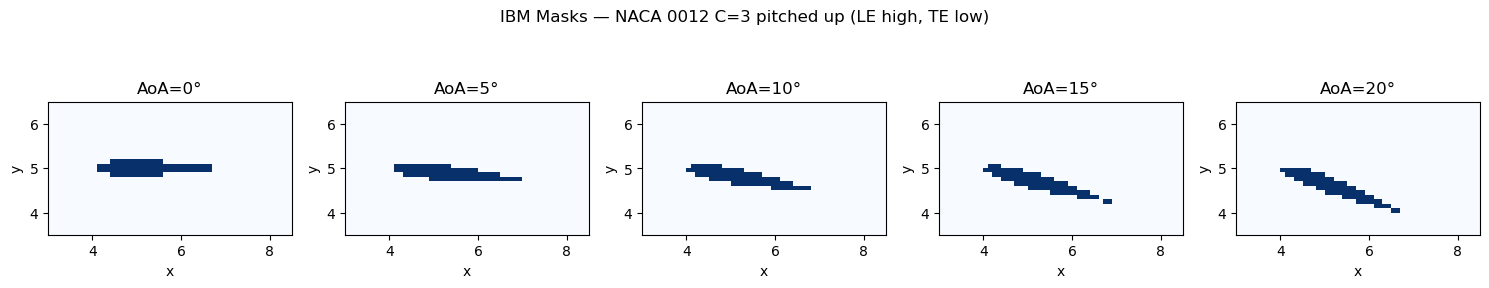

In [15]:
def naca_thickness(xn, t, xp=np):
    xn = xp.clip(xn, 0.0, 1.0)
    return 5*t*(0.2969*xp.sqrt(xn) - 0.1260*xn
                - 0.3516*xn**2 + 0.2843*xn**3 - 0.1015*xn**4)

def make_rotated_mask(aoa_deg, X, Y):
    """IBM mask for NACA 0012 pitched up (LE high, TE low) by aoa_deg.

    x_norm, yt are in normalised chord units [0,1].
    y_af is in PHYSICAL units → must compare against yt * C.
    """
    a  = np.deg2rad(aoa_deg)
    ca = float(np.cos(a));  sa = float(np.sin(a))
    dx_ = X - x_le;  dy_ = Y - y_c
    # CCW into body frame (undoes CW physical pitch-up)
    x_af  =  dx_ * ca - dy_ * sa
    y_af  =  dx_ * sa + dy_ * ca
    x_norm = x_af / C                        # normalised chord position [0,1]
    yt     = naca_thickness(x_norm, t_naca)  # normalised half-thickness
    # y_af is physical; yt*C converts to physical half-thickness
    return (x_norm >= 0) & (x_norm <= 1) & (np.abs(y_af) <= yt * C)

airfoil_masks_cpu = np.stack([make_rotated_mask(aoa, X_cpu, Y_cpu) for aoa in AoA_list])
airfoil_masks_gpu = cp.array(airfoil_masks_cpu)

masks_float_gpu = airfoil_masks_gpu.to(DTYPE)
masks_inv_gpu   = 1.0 - masks_float_gpu

print("IBM mask cells per AoA (C=3, physical half-thickness ≈ 0.18 m):")
for aoa, m in zip(AoA_list, airfoil_masks_cpu):
    print(f"  AoA={aoa:2d}°: {m.sum():4d} cells  ({m.mean()*100:.2f}%)")

xn_plt = np.linspace(0, 1, 300)
yt_plt = naca_thickness(xn_plt, t_naca)

fig, axes = plt.subplots(1, n_aoa, figsize=(15, 3))
for i, (aoa, ax) in enumerate(zip(AoA_list, axes)):
    ax.imshow(airfoil_masks_cpu[i], origin='lower', cmap='Blues',
              extent=[0, Lx, 0, Ly], aspect='equal')
    ax.set_xlim(3.0, 8.5); ax.set_ylim(3.5, 6.5)
    ax.set_title(f'AoA={aoa}°'); ax.set_xlabel('x'); ax.set_ylabel('y')
plt.suptitle('IBM Masks — NACA 0012 C=3 pitched up (LE high, TE low)')
plt.tight_layout(); plt.show()

def airfoil_patch(aoa_deg=0, color='gray'):
    """Smooth NACA 0012 polygon (CW rotation = pitched up: TE below LE)."""
    xs = np.concatenate([xn_plt, xn_plt[::-1]])
    ys = np.concatenate([yt_plt, -yt_plt[::-1]])
    xc = x_le + xs * C
    yc = y_c  + ys * C   # physical thickness = normalised * C
    if aoa_deg != 0:
        a  = np.deg2rad(aoa_deg)
        ca, sa = np.cos(a), np.sin(a)
        dx_ = xc - x_le;  dy_ = yc - y_c
        xc  = x_le + dx_*ca + dy_*sa
        yc  = y_c  - dx_*sa + dy_*ca
    return plt.Polygon(np.column_stack([xc, yc]), color=color, zorder=5)

## 4  Initial Conditions  (shape: n_aoa × Ny × Nx)

In [16]:
# ── Initial conditions: horizontal flow, no-slip inside each rotated mask ─────
u = U_inf * cp.ones((n_aoa, Ny, Nx))
v = cp.zeros((n_aoa, Ny, Nx))
p = cp.zeros((n_aoa, Ny, Nx))

u *= masks_inv_gpu
v *= masks_inv_gpu

mb = u.element_size() * u.nelement() / 1e6   # torch uses element_size() not nbytes
print(f"Field shape : {tuple(u.shape)}   ({mb:.1f} MB per field)")
print(f"Inlet BC    : U={U_inf:.2f} horizontal, V=0  (identical for ALL AoA)")

Field shape : (5, 100, 220)   (0.4 MB per field)
Inlet BC    : U=0.33 horizontal, V=0  (identical for ALL AoA)


## 5  Algorithm — Batched GPU Functions

Every function operates on `(n_aoa, Ny, Nx)` arrays.
Interior slices use `[:, 1:-1, 1:-1]`; boundary assignments use `[:, :, 0]` etc.

In [17]:
def apply_bc(u, v):
    """Apply BCs for all AoA simultaneously.
    
    Inlet is ALWAYS horizontal (U_inf, 0) — the same for every AoA.
    Per-AoA rotated solid is enforced by float-mask multiplication (vectorised,
    no Python loop, avoids advanced GPU scatter).
    """
    # Inlet — horizontal for every AoA
    u[:, :, 0] = U_inf
    v[:, :, 0] = 0.0
    # Outlet — zero gradient
    u[:, :, -1] = u[:, :, -2]
    v[:, :, -1] = v[:, :, -2]
    # Top / bottom — free-slip
    u[:, 0, :]  = u[:, 1, :];   v[:, 0, :]  = 0.0
    u[:, -1, :] = u[:, -2, :];  v[:, -1, :] = 0.0
    # Rotated airfoil — no-slip via vectorised float multiply
    u *= masks_inv_gpu   # 0 inside each AoA's solid, 1 in fluid
    v *= masks_inv_gpu
    return u, v

In [18]:
def momentum_predictor(u, v, p, dx, dy, dt, Nu):
    """Explicit forward step for (u*, v*) — upwind convection + central diffusion."""
    un = u.clone();  vn = v.clone()   # .clone() for torch tensors (was .copy())
    us = un.clone(); vs = vn.clone()

    ui = un[:, 1:-1, 1:-1];  vi = vn[:, 1:-1, 1:-1]

    u_e = un[:, 1:-1, 2:];   u_w = un[:, 1:-1, :-2]
    u_n = un[:, 2:, 1:-1];   u_s = un[:, :-2, 1:-1]
    v_e = vn[:, 1:-1, 2:];   v_w = vn[:, 1:-1, :-2]
    v_n = vn[:, 2:, 1:-1];   v_s = vn[:, :-2, 1:-1]

    # Upwind convection
    cu_x = cp.maximum(ui,0)*(ui-u_w)/dx + cp.minimum(ui,0)*(u_e-ui)/dx
    cu_y = cp.maximum(vi,0)*(ui-u_s)/dy + cp.minimum(vi,0)*(u_n-ui)/dy
    cv_x = cp.maximum(ui,0)*(vi-v_w)/dx + cp.minimum(ui,0)*(v_e-vi)/dx
    cv_y = cp.maximum(vi,0)*(vi-v_s)/dy + cp.minimum(vi,0)*(v_n-vi)/dy

    # Central diffusion
    du = Nu*((u_e-2*ui+u_w)/dx**2 + (u_n-2*ui+u_s)/dy**2)
    dv = Nu*((v_e-2*vi+v_w)/dx**2 + (v_n-2*vi+v_s)/dy**2)

    us[:, 1:-1, 1:-1] = ui + dt*(du - cu_x - cu_y)
    vs[:, 1:-1, 1:-1] = vi + dt*(dv - cv_x - cv_y)
    return us, vs

In [19]:
def compute_divergence(us, vs, dx, dy):
    return ((us[:, 1:-1, 2:] - us[:, 1:-1, :-2]) / (2*dx)
           +(vs[:, 2:, 1:-1] - vs[:, :-2, 1:-1]) / (2*dy))


def pressure_poisson(us, vs, p, dx, dy, dt, rho=1.0, nit=50):
    """Fixed-iteration Jacobi — GPU-friendly (no conditional branching per batch)."""
    for _ in range(nit):
        p_e = p[:, 1:-1, 2:];   p_w = p[:, 1:-1, :-2]
        p_n = p[:, 2:, 1:-1];   p_s = p[:, :-2, 1:-1]
        rhs = (rho/dt) * compute_divergence(us, vs, dx, dy)
        p[:, 1:-1, 1:-1] = ((p_e+p_w)*dy**2 + (p_n+p_s)*dx**2
                            - rhs*dx**2*dy**2) / (2*(dx**2+dy**2))
        # Neumann
        p[:, 0, :]  = p[:, 1, :];   p[:, -1, :] = p[:, -2, :]
        p[:, :, 0]  = p[:, :, 1];   p[:, :, -1] = p[:, :, -2]
        p[:, :, -1] = 0.0           # Dirichlet reference at outlet
    return p


def velocity_corrector(us, vs, p, dx, dy, dt, rho=1.0):
    u = us.clone();  v = vs.clone()   # .clone() for torch tensors (was .copy())
    p_e = p[:, 1:-1, 2:];  p_w = p[:, 1:-1, :-2]
    p_n = p[:, 2:, 1:-1];  p_s = p[:, :-2, 1:-1]
    u[:, 1:-1, 1:-1] = us[:, 1:-1, 1:-1] - (dt/rho)*(p_e-p_w)/(2*dx)
    v[:, 1:-1, 1:-1] = vs[:, 1:-1, 1:-1] - (dt/rho)*(p_n-p_s)/(2*dy)
    return u, v

In [20]:
def compute_forces(u, v, rho=1.0):
    """Cd and Cl for all AoA simultaneously. Shape: (n_aoa,).
    
    With horizontal inlet flow:
      Drag  = force in freestream direction (+x) = Fx
      Lift  = force perpendicular to freestream (+y) = Fy
    No wind-axis rotation is needed.

    Sign: the corrector leaves residual velocity inside the solid.
    The body must supply impulse ρ·u·dV/dt to cancel it each step →
    reaction force on body = +ρ·Σ(u_solid)·dx·dy/dt.
    """
    # Vectorised sum: u * masks_float selects only each AoA's solid cells
    Fx = rho * cp.sum(u * masks_float_gpu, axis=(1, 2)) * dx * dy / dt  # (n_aoa,)
    Fy = rho * cp.sum(v * masks_float_gpu, axis=(1, 2)) * dx * dy / dt
    q  = 0.5 * rho * U_inf**2 * C
    return Fx / q, Fy / q   # Cd, Cl

## 6  Main Loop — All AoA in Parallel

In [21]:
drag_hist = cp.zeros((n_aoa, nt))
lift_hist = cp.zeros((n_aoa, nt))
res_hist  = cp.zeros((n_aoa, nt))

t0 = time.time()

for n in range(nt):
    u_old, v_old = u.clone(), v.clone()   # .clone() for torch (was .copy())

    u_old, v_old = apply_bc(u_old, v_old)
    us, vs       = momentum_predictor(u_old, v_old, p, dx, dy, dt, Nu)
    p            = pressure_poisson(us, vs, p, dx, dy, dt)
    u, v         = velocity_corrector(us, vs, p, dx, dy, dt)

    Cd, Cl          = compute_forces(u, v)
    drag_hist[:, n] = Cd
    lift_hist[:, n] = Cl
    res_hist[:, n]  = cp.max(cp.abs(u - u_old), axis=(1, 2))

    u, v = apply_bc(u, v)

    if n % 2000 == 0:
        r = float(cp.max(res_hist[:, n]))
        elapsed = time.time() - t0
        print(f"Step {n:5d} | max residual = {r:.2e} | elapsed {elapsed:.1f}s")

elapsed_total = time.time() - t0
print(f"\nDone — {nt} steps in {elapsed_total:.1f}s  ({nt/elapsed_total:.0f} steps/s)")

drag_cpu = to_numpy(drag_hist)
lift_cpu = to_numpy(lift_hist)
res_cpu  = to_numpy(res_hist)
u_cpu_f  = to_numpy(u)
v_cpu_f  = to_numpy(v)
p_cpu_f  = to_numpy(p)

Step     0 | max residual = 1.42e-01 | elapsed 1.2s
Step  2000 | max residual = 5.39e-02 | elapsed 25.5s
Step  4000 | max residual = 5.40e-02 | elapsed 50.0s
Step  6000 | max residual = 5.40e-02 | elapsed 74.4s
Step  8000 | max residual = 5.40e-02 | elapsed 98.8s
Step 10000 | max residual = 5.40e-02 | elapsed 123.3s
Step 12000 | max residual = 5.40e-02 | elapsed 147.7s
Step 14000 | max residual = 5.40e-02 | elapsed 172.3s
Step 16000 | max residual = 5.40e-02 | elapsed 197.8s
Step 18000 | max residual = 5.40e-02 | elapsed 228.4s

Done — 20000 steps in 254.6s  (79 steps/s)


## 7  Results

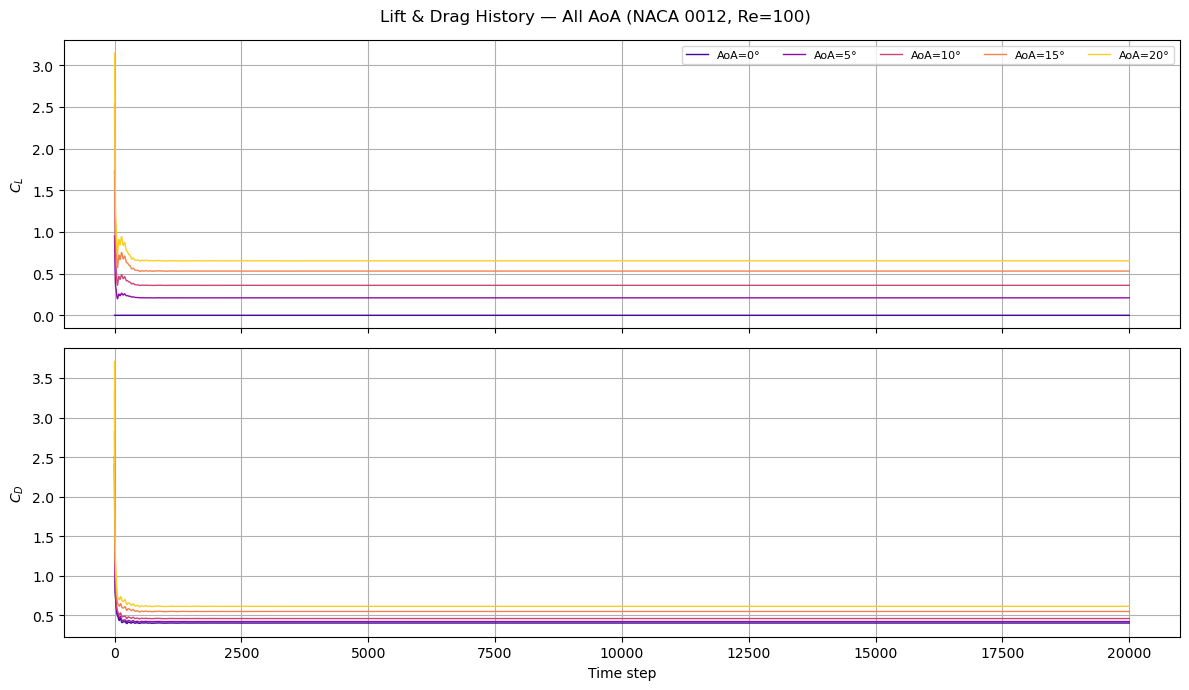

In [40]:
# ── Force-coefficient history ─────────────────────────────────────────────────
colors = plt.cm.plasma(np.linspace(0.1, 0.9, n_aoa))
steps  = np.arange(nt)

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 7), sharex=True)
for i, aoa in enumerate(AoA_list):
    ax1.plot(steps, lift_cpu[i], color=colors[i], label=f'AoA={aoa}°', lw=1)
    ax2.plot(steps, drag_cpu[i], color=colors[i], lw=1)
ax1.set_ylabel('$C_L$');  ax1.legend(ncol=5, fontsize=8);  ax1.grid(True)
ax2.set_ylabel('$C_D$');  ax2.set_xlabel('Time step');      ax2.grid(True)
fig.suptitle('Lift & Drag History — All AoA (NACA 0012, Re=100)')
plt.tight_layout(); plt.show()

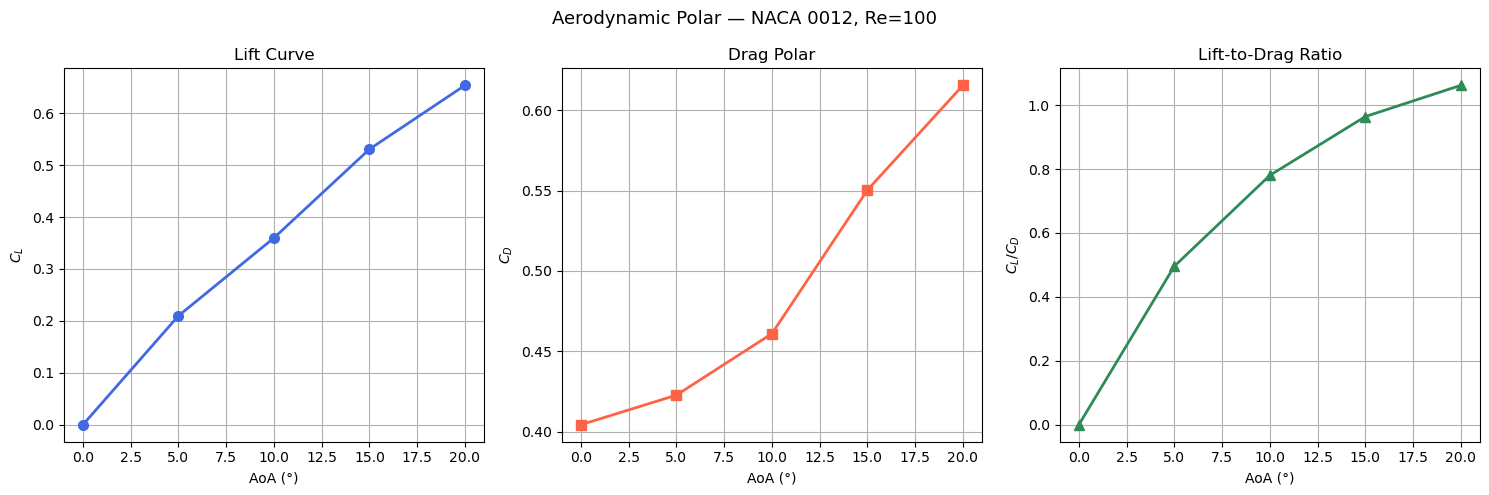


Summary table:
  AoA        Cl        Cd       L/D
-----------------------------------
    0   -0.0000    0.4044    -0.000
    5    0.2097    0.4228     0.496
   10    0.3597    0.4610     0.780
   15    0.5306    0.5503     0.964
   20    0.6536    0.6155     1.062


In [41]:
# ── Aerodynamic Polar ─────────────────────────────────────────────────────────
# Use time-average of last 2000 steps as "converged" value
window = 2000
Cl_mean = lift_cpu[:, -window:].mean(axis=1)   # (n_aoa,)
Cd_mean = drag_cpu[:, -window:].mean(axis=1)
LoD     = Cl_mean / np.where(Cd_mean != 0, Cd_mean, np.nan)

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

axes[0].plot(AoA_list, Cl_mean, 'o-', color='royalblue', lw=2, ms=7)
axes[0].set_xlabel('AoA (°)'); axes[0].set_ylabel('$C_L$')
axes[0].set_title('Lift Curve'); axes[0].grid(True)

axes[1].plot(AoA_list, Cd_mean, 's-', color='tomato', lw=2, ms=7)
axes[1].set_xlabel('AoA (°)'); axes[1].set_ylabel('$C_D$')
axes[1].set_title('Drag Polar'); axes[1].grid(True)

axes[2].plot(AoA_list, LoD, '^-', color='seagreen', lw=2, ms=7)
axes[2].set_xlabel('AoA (°)'); axes[2].set_ylabel('$C_L / C_D$')
axes[2].set_title('Lift-to-Drag Ratio'); axes[2].grid(True)

fig.suptitle('Aerodynamic Polar — NACA 0012, Re=100', fontsize=13)
plt.tight_layout(); plt.show()

print("\nSummary table:")
print(f"{'AoA':>5}  {'Cl':>8}  {'Cd':>8}  {'L/D':>8}")
print("-" * 35)
for i, aoa in enumerate(AoA_list):
    print(f"{aoa:>5}  {Cl_mean[i]:>8.4f}  {Cd_mean[i]:>8.4f}  {LoD[i]:>8.3f}")

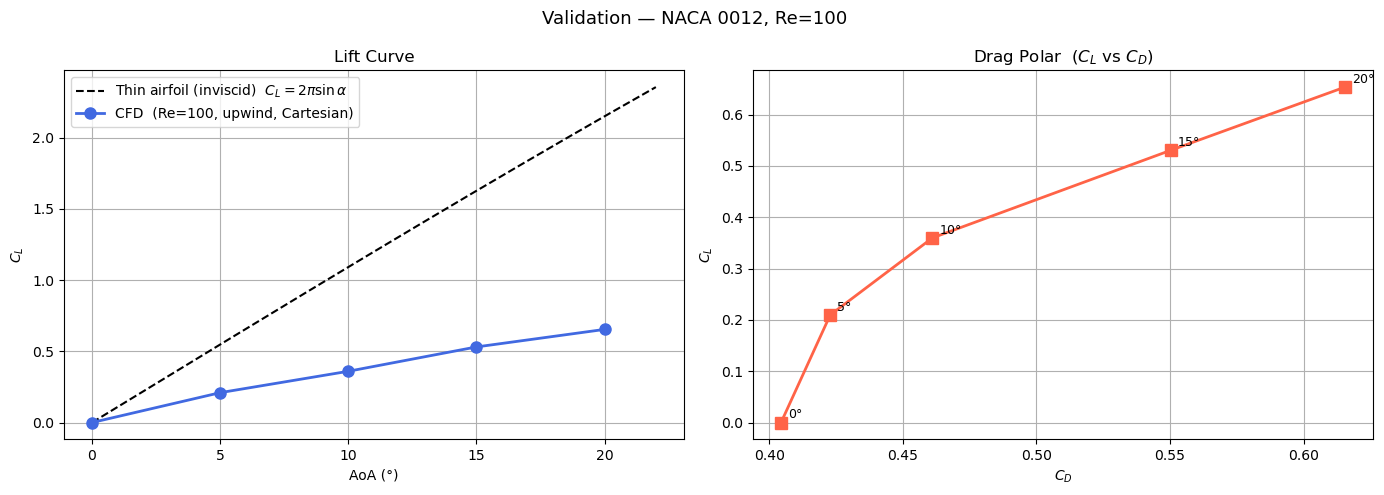

  AoA    Cl_CFD   Cl_theory    Cd_CFD      L/D  note
--------------------------------------------------------------
    0°   -0.0000      0.0000    0.4044    -0.00  
    5°    0.2097      0.5476    0.4228     0.50  (separation?)
   10°    0.3597      1.0911    0.4610     0.78  (separation?)
   15°    0.5306      1.6262    0.5503     0.96  (separation?)
   20°    0.6536      2.1490    0.6155     1.06  (separation?)

Expected behaviour at Re=100 vs inviscid theory:
  • Cl(0°)  should be ≈ 0            (symmetry check)
  • Cl slope < 2π/rad               (viscous deficit)
  • Cd rises steeply at high AoA    (separation drag)

  Symmetry check  Cl(0°) = -0.00000  (ideal = 0)


In [42]:
# ── Validation: Cl vs Thin Airfoil Theory ─────────────────────────────────────
# Thin airfoil (inviscid): Cl = 2π sin(α).  At Re=100 viscosity reduces Cl.

alpha_ref = np.linspace(0, 22, 200)
Cl_theory = 2 * np.pi * np.sin(np.deg2rad(alpha_ref))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: lift curve
ax = axes[0]
ax.plot(alpha_ref, Cl_theory, 'k--', lw=1.5,
        label='Thin airfoil (inviscid)  $C_L=2\\pi\\sin\\alpha$')
ax.plot(AoA_list, Cl_mean, 'o-', color='royalblue', lw=2, ms=8,
        label='CFD  (Re=100, upwind, Cartesian)')
ax.set_xlabel('AoA (°)'); ax.set_ylabel('$C_L$')
ax.set_title('Lift Curve'); ax.legend(); ax.grid(True)

# Right: drag polar  Cl vs Cd
ax = axes[1]
ax.plot(Cd_mean, Cl_mean, 's-', color='tomato', lw=2, ms=8)
for i, aoa in enumerate(AoA_list):
    ax.annotate(f'{aoa}°', (Cd_mean[i], Cl_mean[i]),
                textcoords='offset points', xytext=(5, 3), fontsize=9)
ax.set_xlabel('$C_D$'); ax.set_ylabel('$C_L$')
ax.set_title('Drag Polar  ($C_L$ vs $C_D$)'); ax.grid(True)

fig.suptitle('Validation — NACA 0012, Re=100', fontsize=13)
plt.tight_layout(); plt.show()

# Validation table
print(f"{'AoA':>5}  {'Cl_CFD':>8}  {'Cl_theory':>10}  {'Cd_CFD':>8}  {'L/D':>7}  {'note'}")
print('-' * 62)
for i, aoa in enumerate(AoA_list):
    Cl_th = 2 * np.pi * np.sin(np.deg2rad(aoa))
    err   = abs(Cl_mean[i] - Cl_th)
    note  = '(separation?)' if Cl_mean[i] < Cl_th * 0.7 and aoa > 0 else ''
    print(f"{aoa:>5}°  {Cl_mean[i]:>8.4f}  {Cl_th:>10.4f}  {Cd_mean[i]:>8.4f}  {LoD[i]:>7.2f}  {note}")
print()
print('Expected behaviour at Re=100 vs inviscid theory:')
print('  • Cl(0°)  should be ≈ 0            (symmetry check)')
print('  • Cl slope < 2π/rad               (viscous deficit)')
print('  • Cd rises steeply at high AoA    (separation drag)')
sym_err = abs(Cl_mean[0])
print(f'\n  Symmetry check  Cl(0°) = {Cl_mean[0]:.5f}  (ideal = 0)')

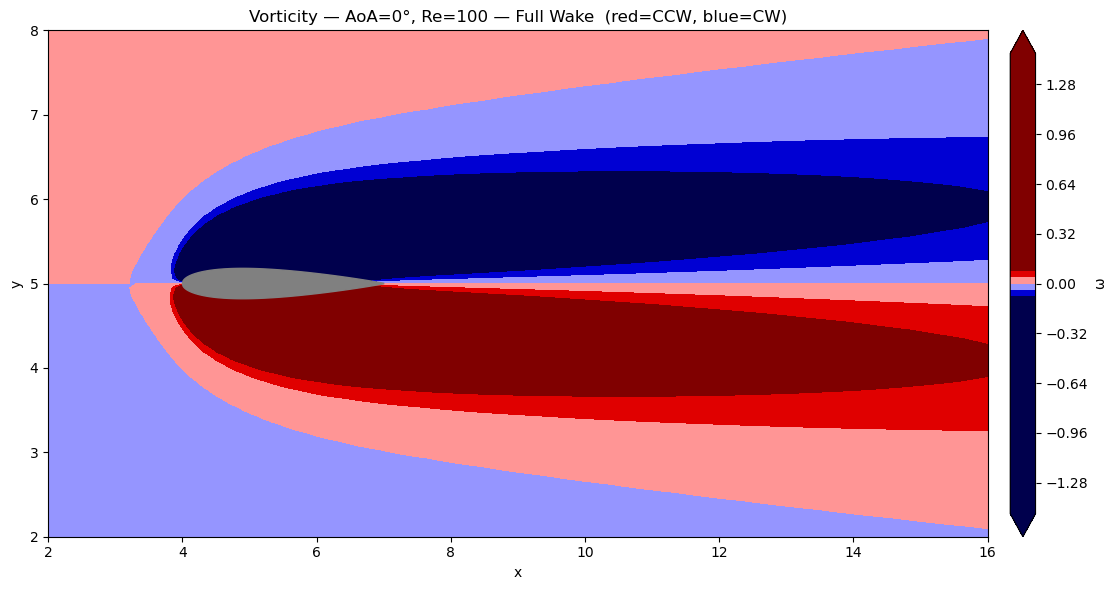

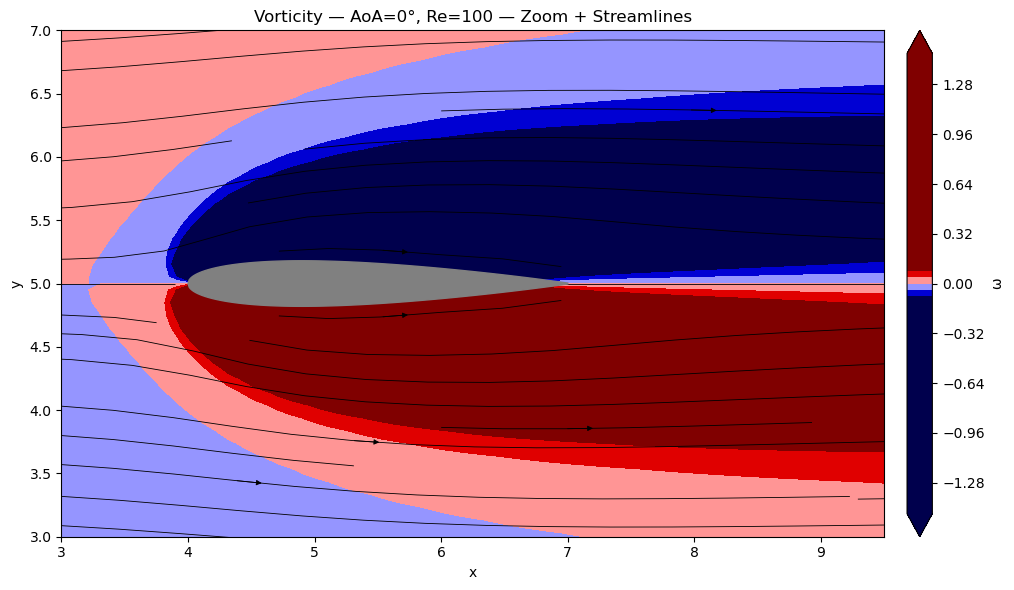

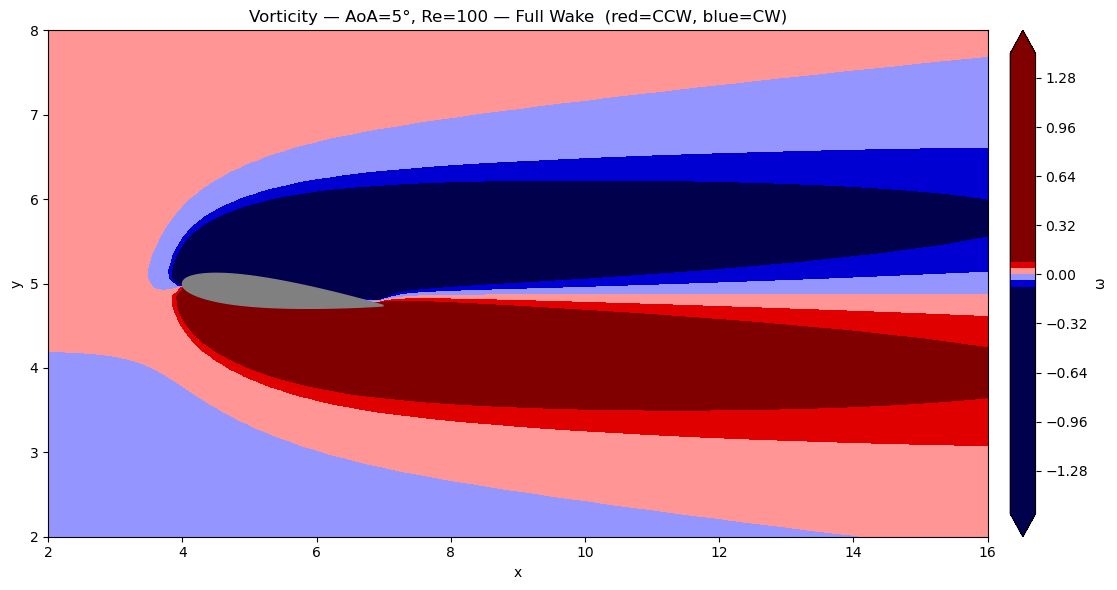

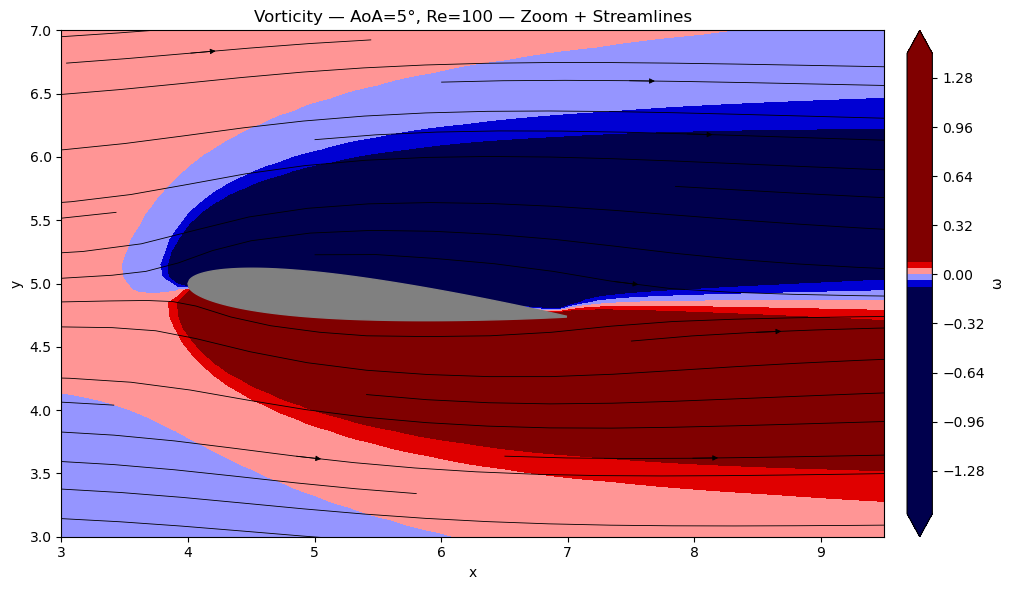

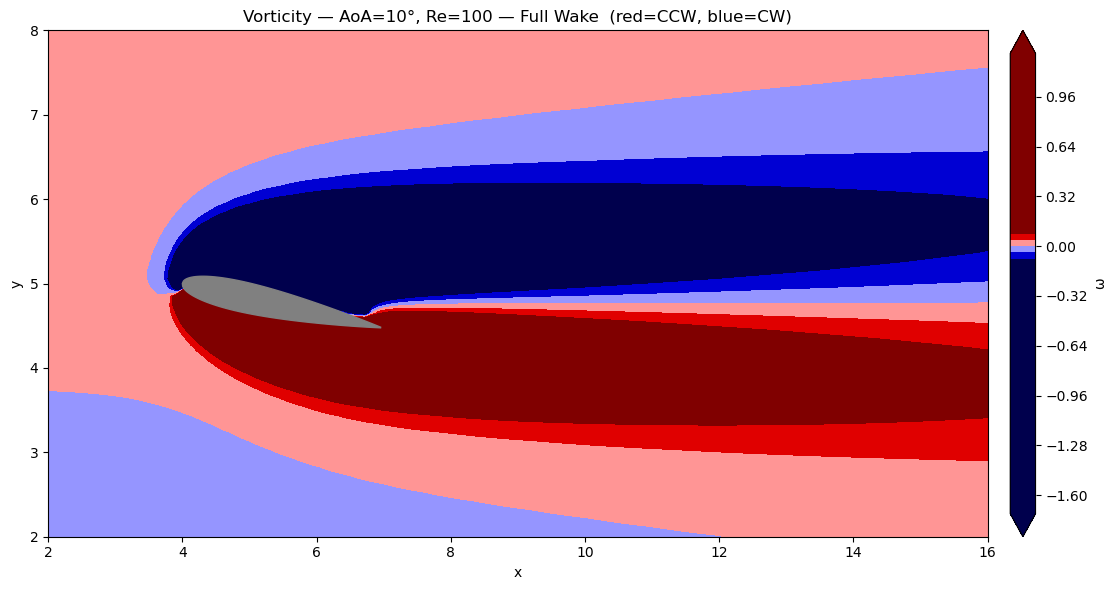

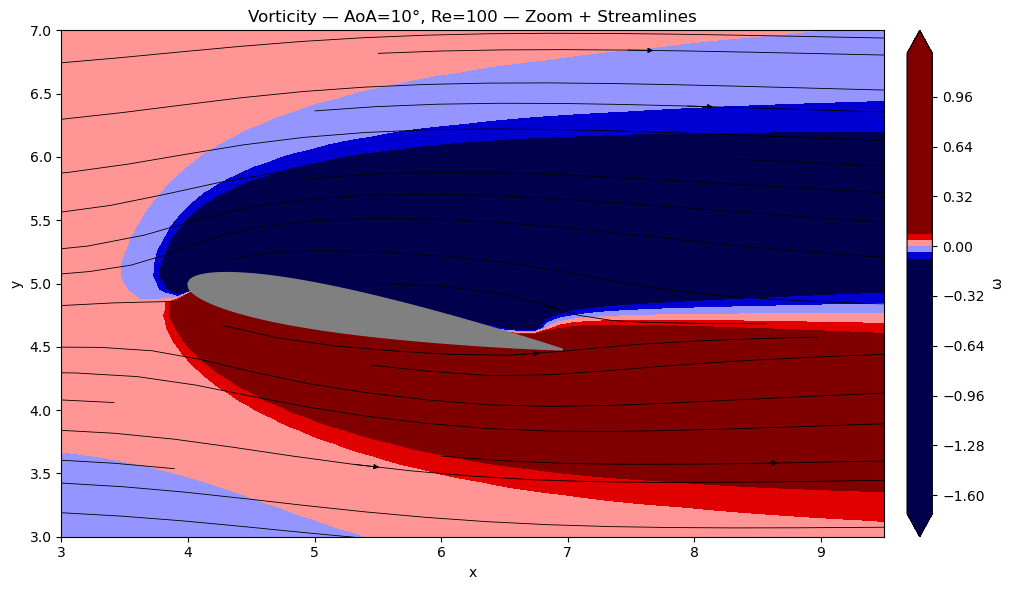

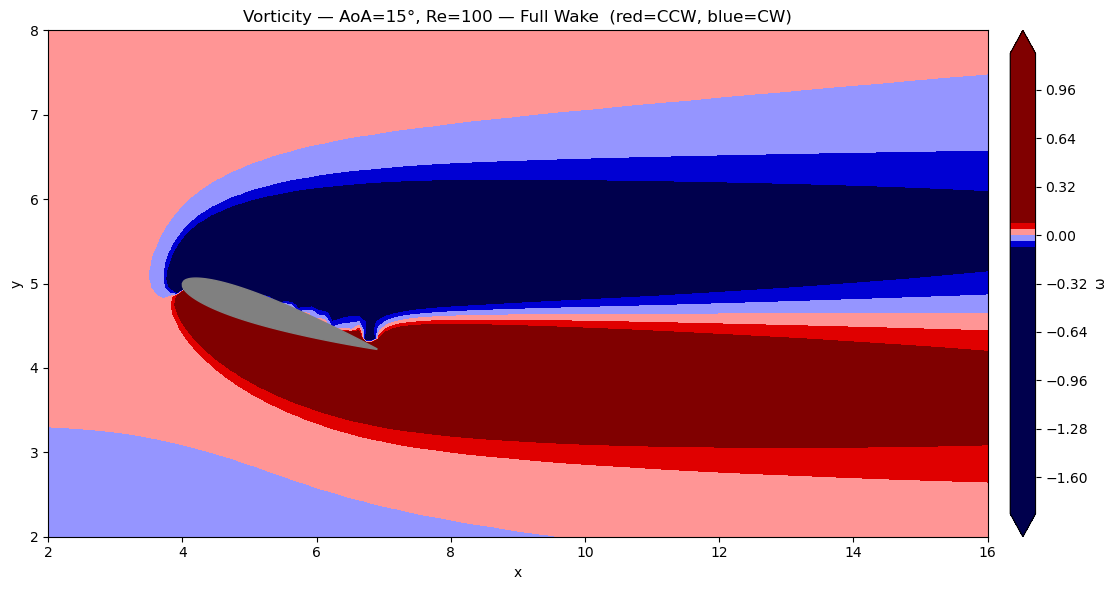

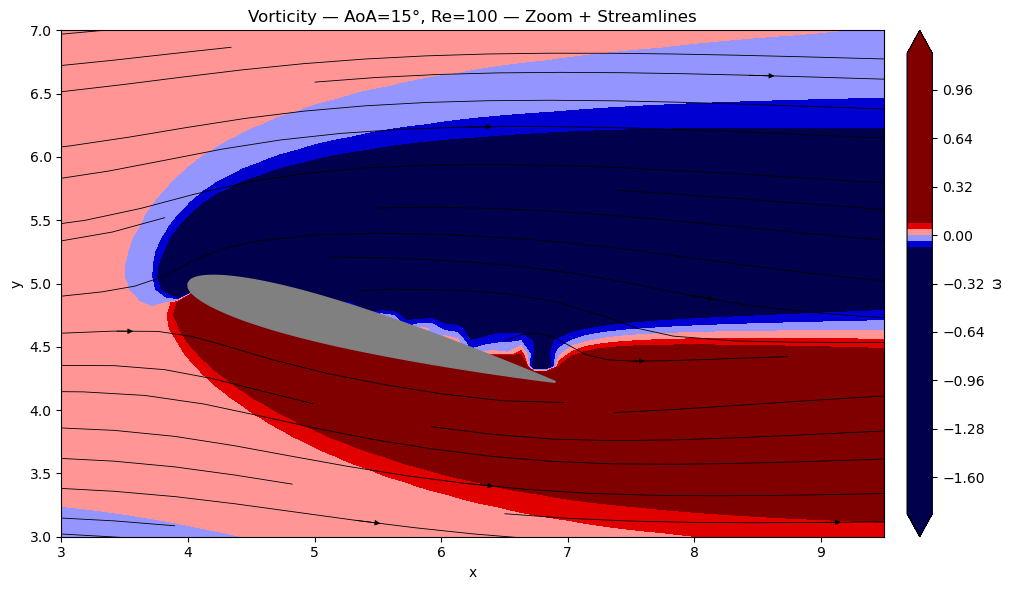

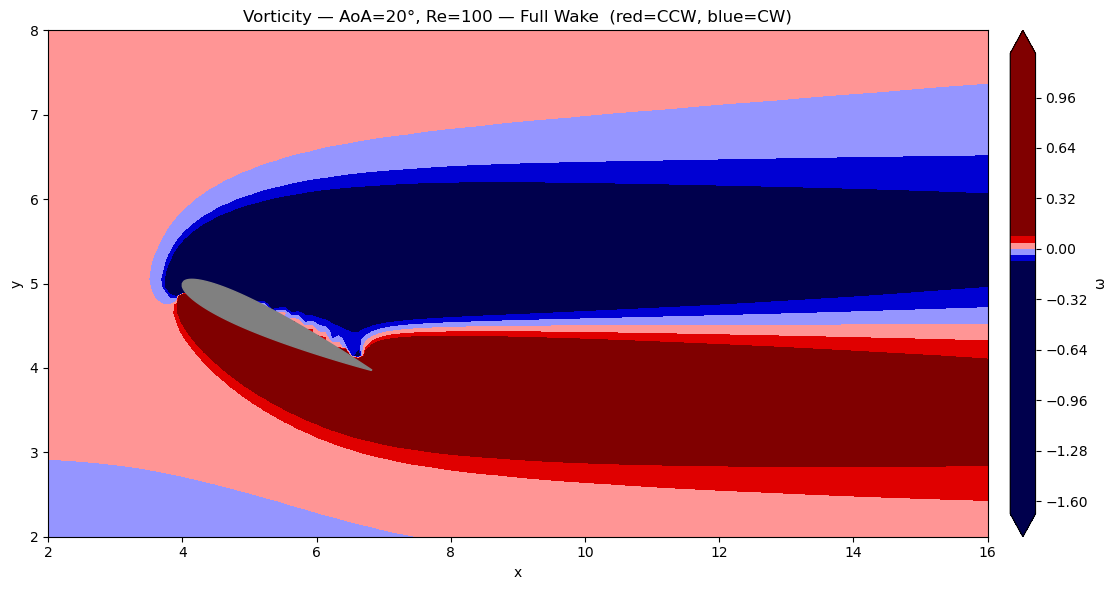

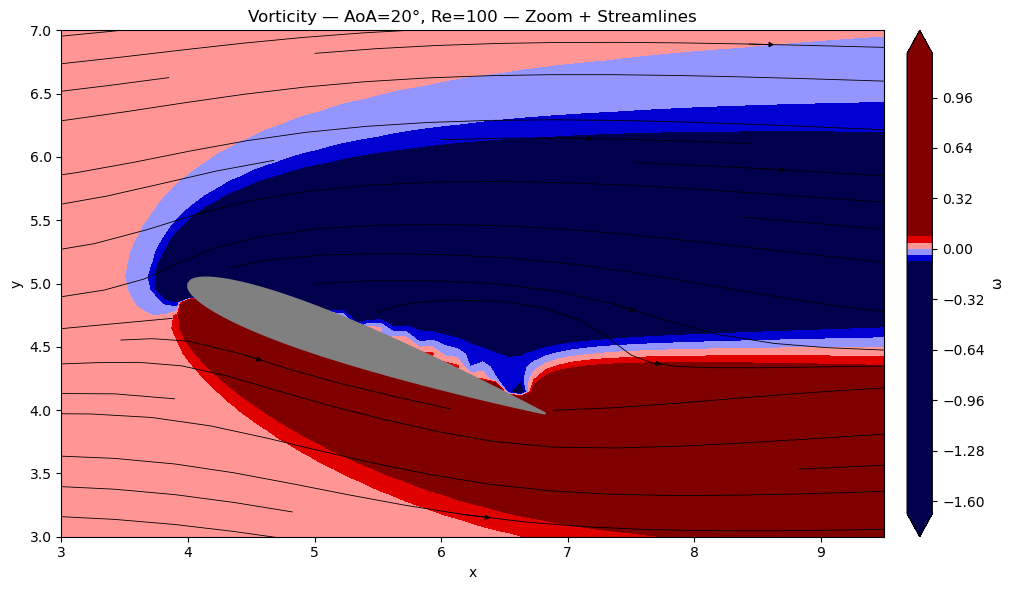

In [43]:
# ── Vorticity: full wake + zoom ───────────────────────────────────────────────
# C=3, x_le=4: AoA=0 TE at (7,5); AoA=20° pitched-up TE at (6.82, 3.97)
ZOOM_X = (3.0, 9.5)
ZOOM_Y = (3.0, 7.0)

omega_all = []
for i in range(n_aoa):
    om = ((v_cpu_f[i, 1:-1, 2:] - v_cpu_f[i, 1:-1, :-2]) / (2*dx)
         -(u_cpu_f[i, 2:, 1:-1] - u_cpu_f[i, :-2, 1:-1]) / (2*dy))
    omega_all.append(om)

vlim  = max(np.percentile(np.abs(o), 85) for o in omega_all)
Xin   = X_cpu[1:-1, 1:-1]
Yin   = Y_cpu[1:-1, 1:-1]
kw_om = dict(levels=80, cmap='seismic', vmin=-vlim, vmax=vlim, extend='both')

for i, aoa in enumerate(AoA_list):
    omega = omega_all[i]
    af_i  = airfoil_masks_cpu[i]
    u_pl  = u_cpu_f[i].copy(); u_pl[af_i] = np.nan
    v_pl  = v_cpu_f[i].copy(); v_pl[af_i] = np.nan

    fig, ax = plt.subplots(figsize=(12, 6))
    im = ax.contourf(Xin, Yin, omega, **kw_om)
    ax.add_patch(airfoil_patch(aoa_deg=aoa))
    ax.set_xlim(2, 16); ax.set_ylim(2, 8)
    ax.set_xlabel('x'); ax.set_ylabel('y')
    ax.set_title(f'Vorticity — AoA={aoa}°, Re=100 — Full Wake  (red=CCW, blue=CW)')
    fig.colorbar(im, ax=ax, label='ω', pad=0.02)
    plt.tight_layout(); plt.show()

    fig, ax = plt.subplots(figsize=(12, 6))
    im = ax.contourf(Xin, Yin, omega, **kw_om)
    ax.streamplot(X_cpu, Y_cpu, u_pl, v_pl,
                  density=1.5, color='k', linewidth=0.6, arrowsize=0.8)
    ax.add_patch(airfoil_patch(aoa_deg=aoa))
    ax.set_xlim(*ZOOM_X); ax.set_ylim(*ZOOM_Y)
    ax.set_aspect('equal')
    ax.set_xlabel('x'); ax.set_ylabel('y')
    ax.set_title(f'Vorticity — AoA={aoa}°, Re=100 — Zoom + Streamlines')
    fig.colorbar(im, ax=ax, label='ω', pad=0.02)
    plt.tight_layout(); plt.show()

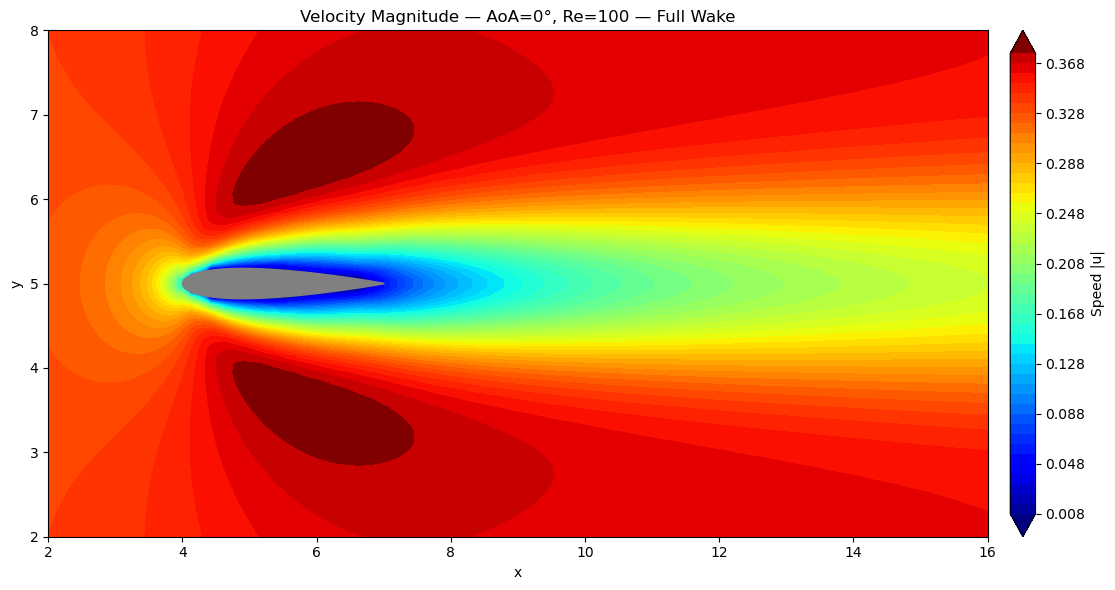

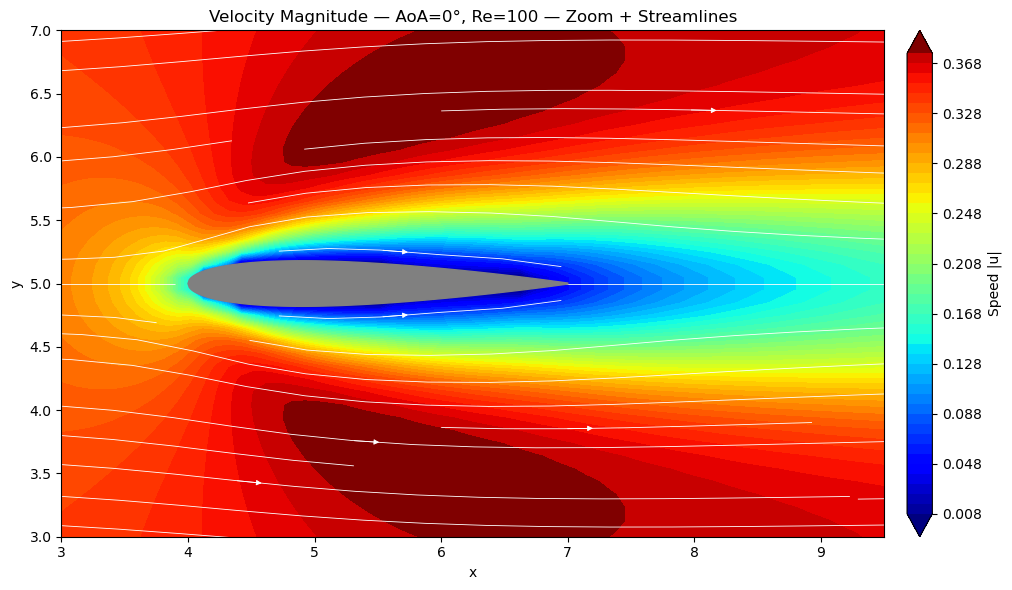

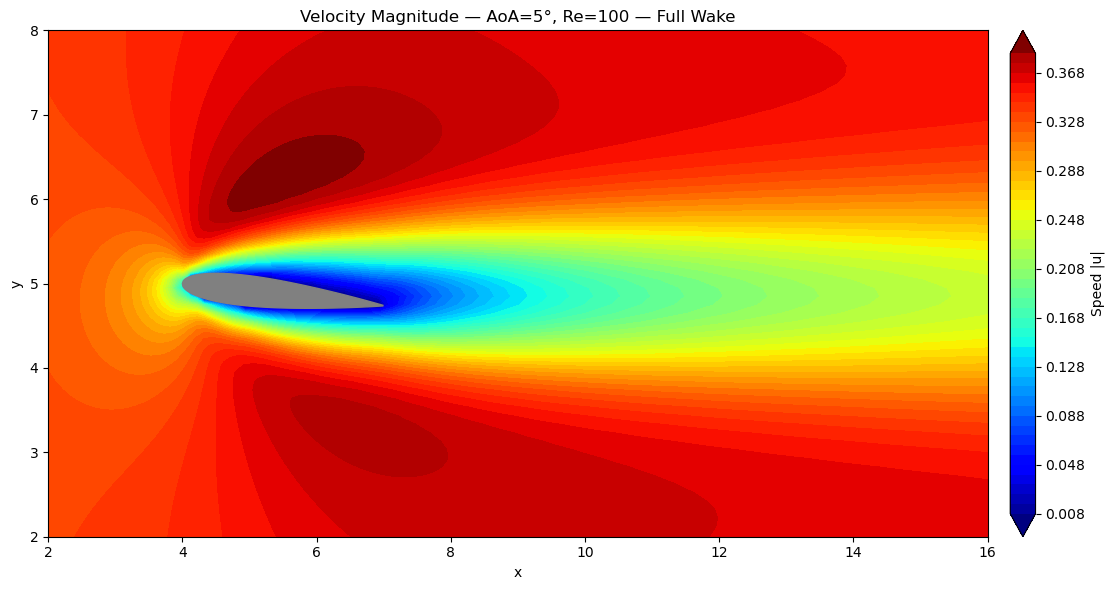

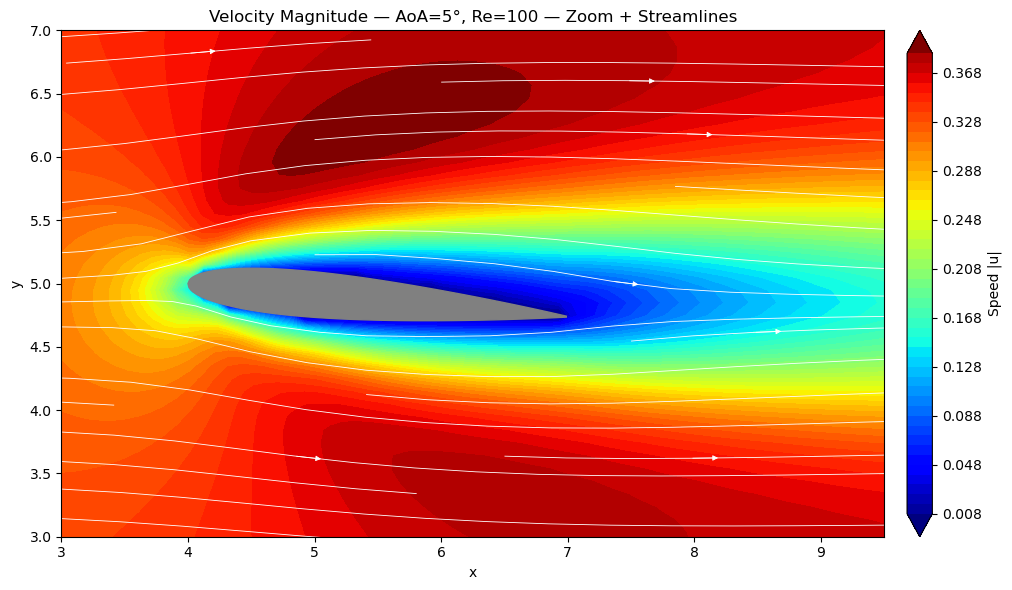

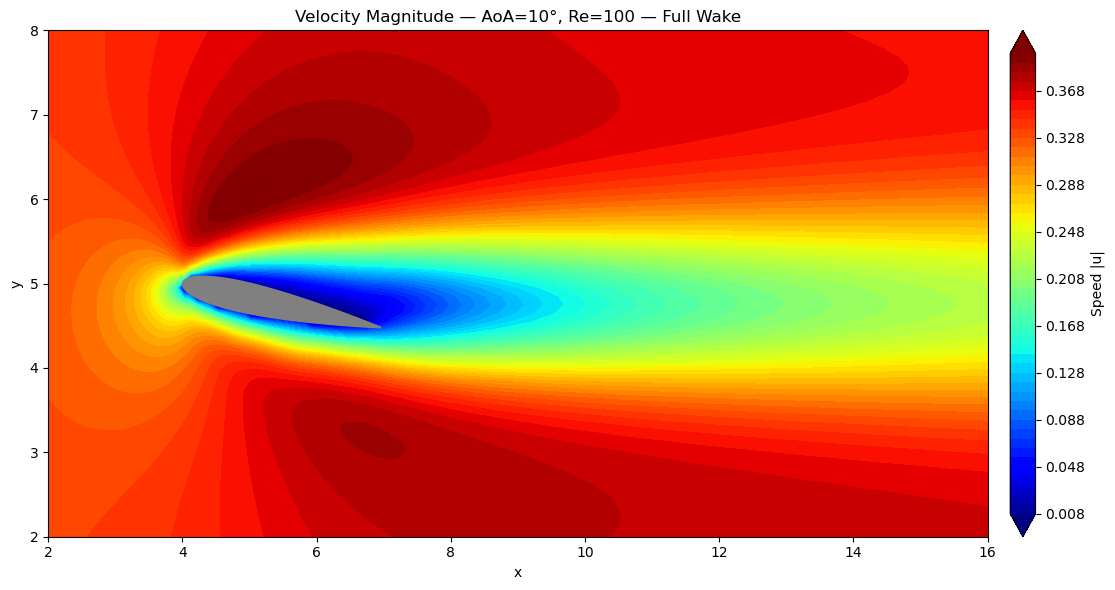

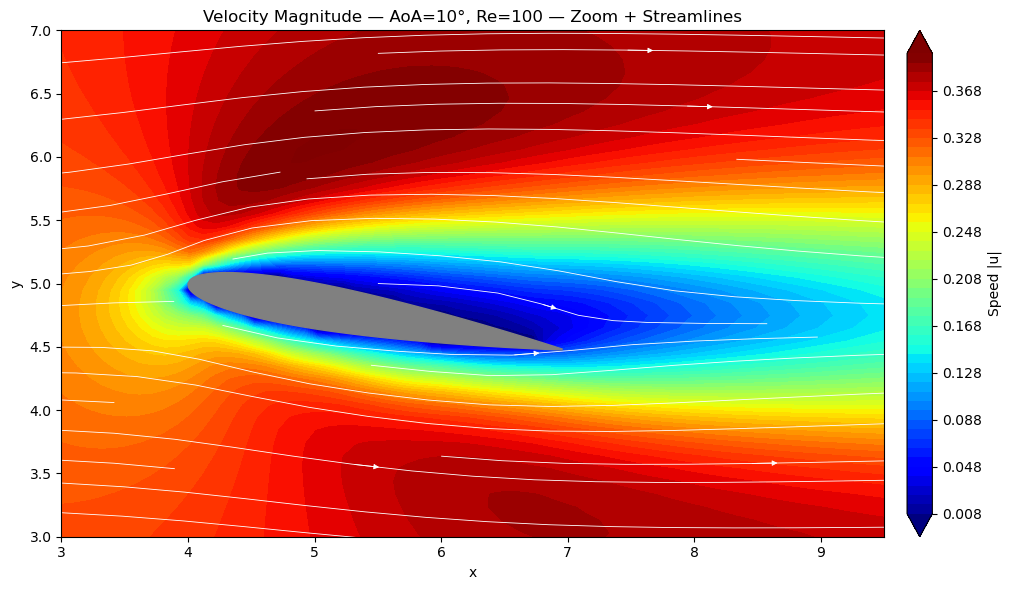

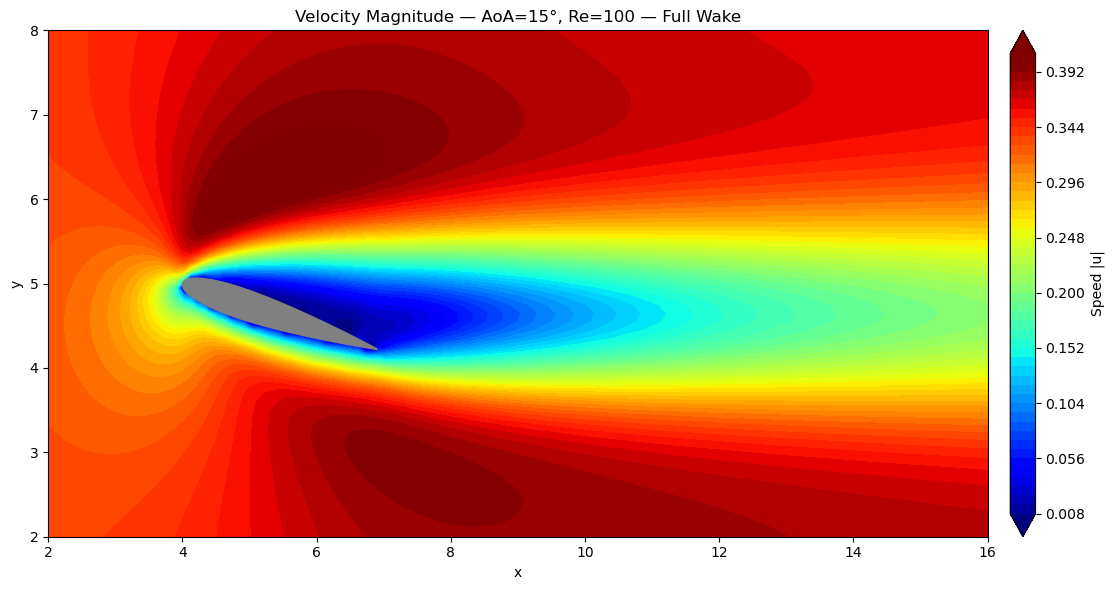

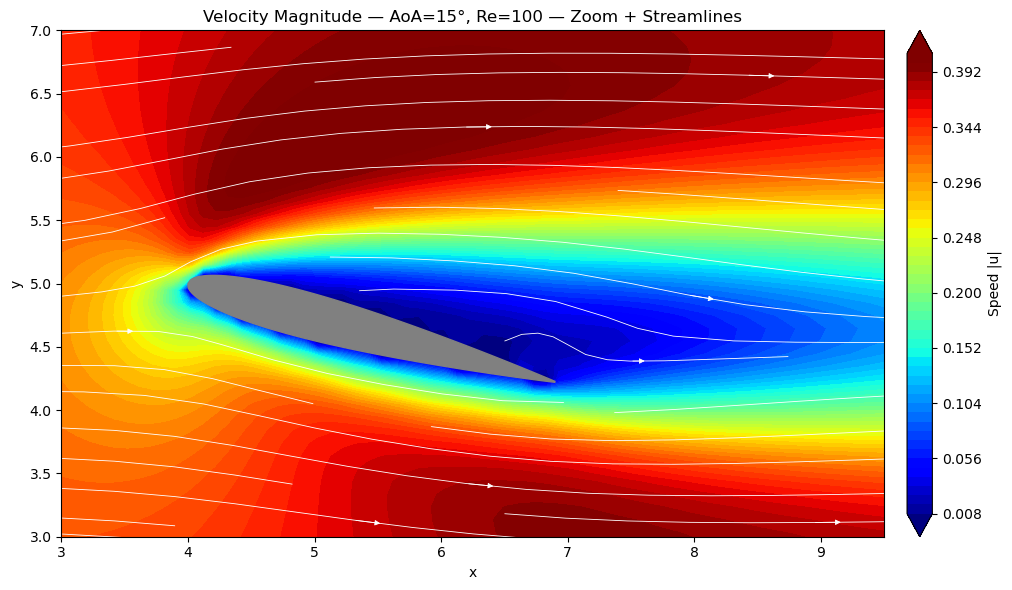

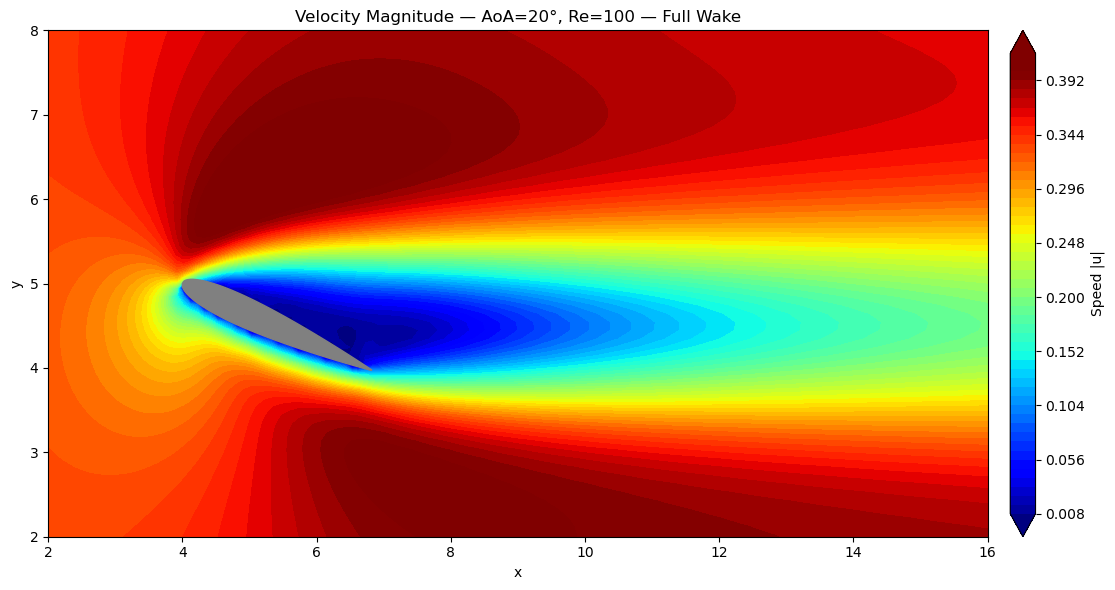

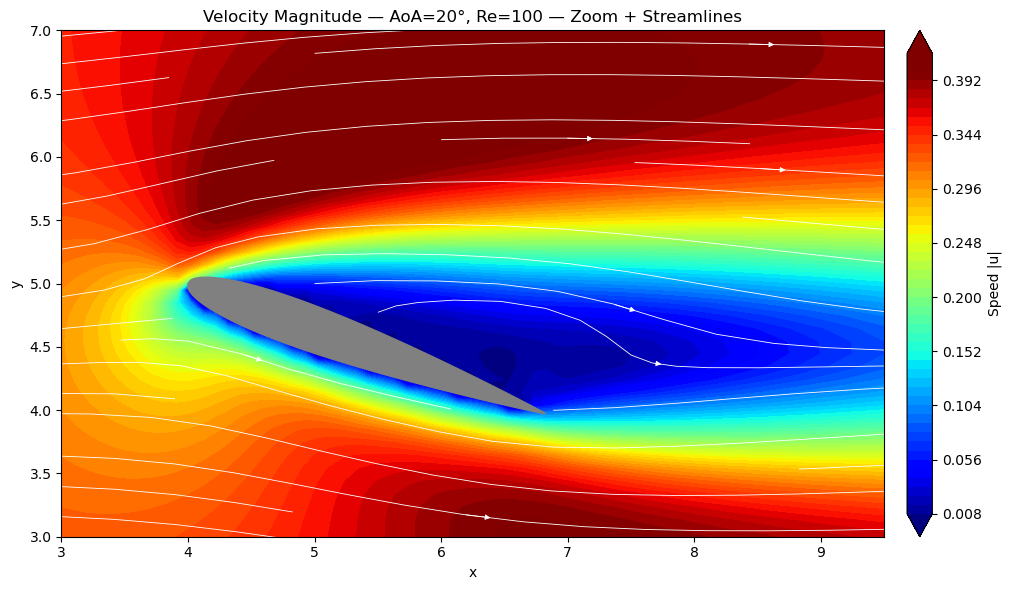

In [44]:
# ── Velocity magnitude ────────────────────────────────────────────────────────
ZOOM_X = (3.0, 9.5)
ZOOM_Y = (3.0, 7.0)

speed_all = np.sqrt(u_cpu_f**2 + v_cpu_f**2)
vmax_g = np.percentile(speed_all, 99)
kw_sp  = dict(levels=60, cmap='jet', vmin=0, vmax=vmax_g, extend='both')

for i, aoa in enumerate(AoA_list):
    af_i = airfoil_masks_cpu[i]
    u_pl = u_cpu_f[i].copy(); u_pl[af_i] = np.nan
    v_pl = v_cpu_f[i].copy(); v_pl[af_i] = np.nan

    fig, ax = plt.subplots(figsize=(12, 6))
    im = ax.contourf(X_cpu, Y_cpu, speed_all[i], **kw_sp)
    ax.add_patch(airfoil_patch(aoa_deg=aoa))
    ax.set_xlim(2, 16); ax.set_ylim(2, 8)
    ax.set_xlabel('x'); ax.set_ylabel('y')
    ax.set_title(f'Velocity Magnitude — AoA={aoa}°, Re=100 — Full Wake')
    fig.colorbar(im, ax=ax, label='Speed |u|', pad=0.02)
    plt.tight_layout(); plt.show()

    fig, ax = plt.subplots(figsize=(12, 6))
    im = ax.contourf(X_cpu, Y_cpu, speed_all[i], **kw_sp)
    ax.streamplot(X_cpu, Y_cpu, u_pl, v_pl,
                  density=1.5, color='white', linewidth=0.6, arrowsize=0.8)
    ax.add_patch(airfoil_patch(aoa_deg=aoa))
    ax.set_xlim(*ZOOM_X); ax.set_ylim(*ZOOM_Y)
    ax.set_aspect('equal')
    ax.set_xlabel('x'); ax.set_ylabel('y')
    ax.set_title(f'Velocity Magnitude — AoA={aoa}°, Re=100 — Zoom + Streamlines')
    fig.colorbar(im, ax=ax, label='Speed |u|', pad=0.02)
    plt.tight_layout(); plt.show()

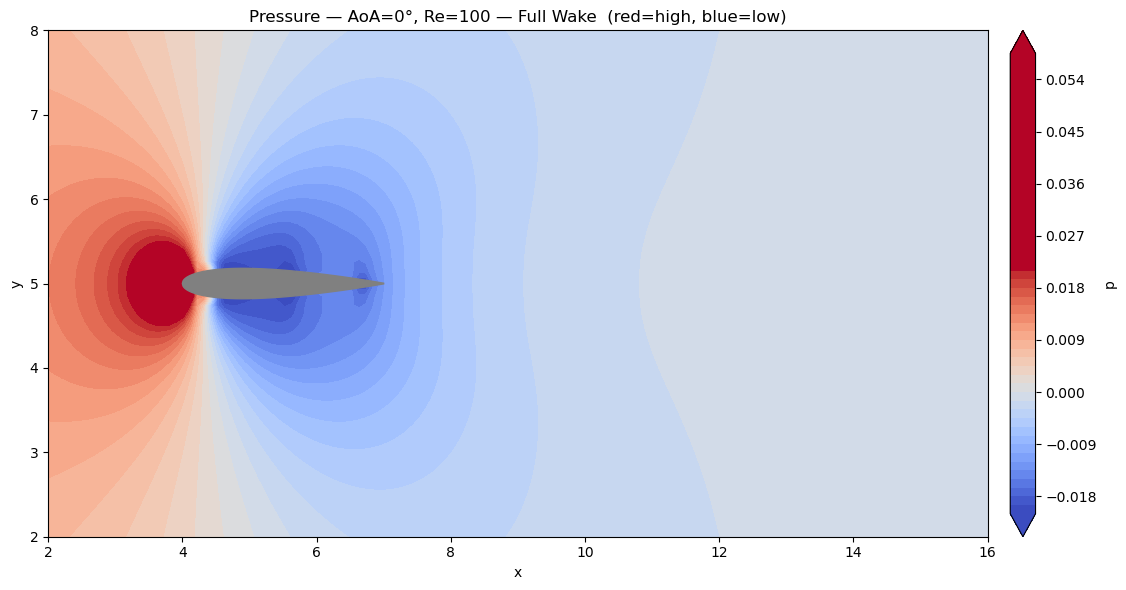

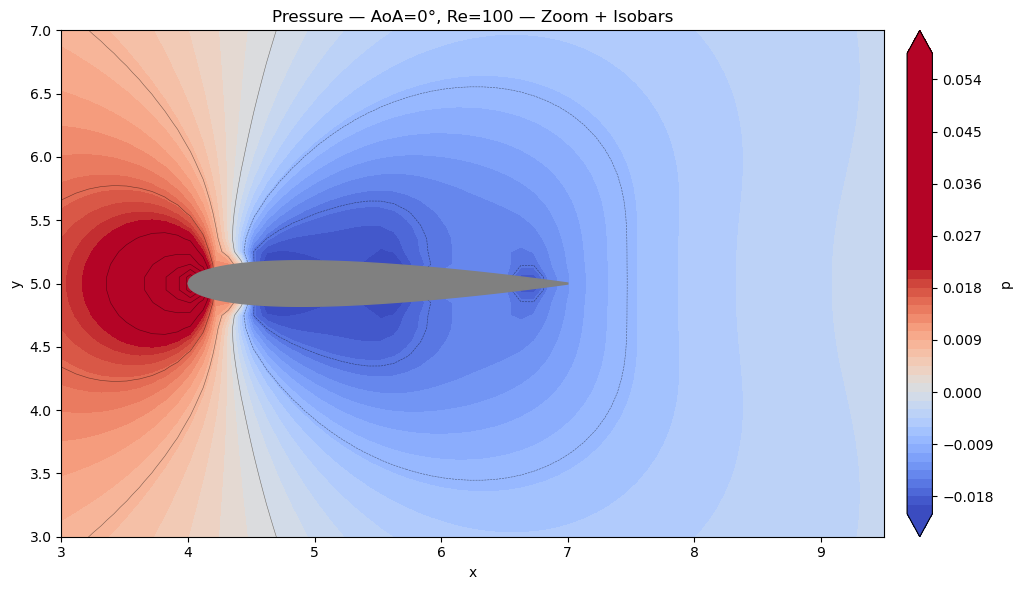

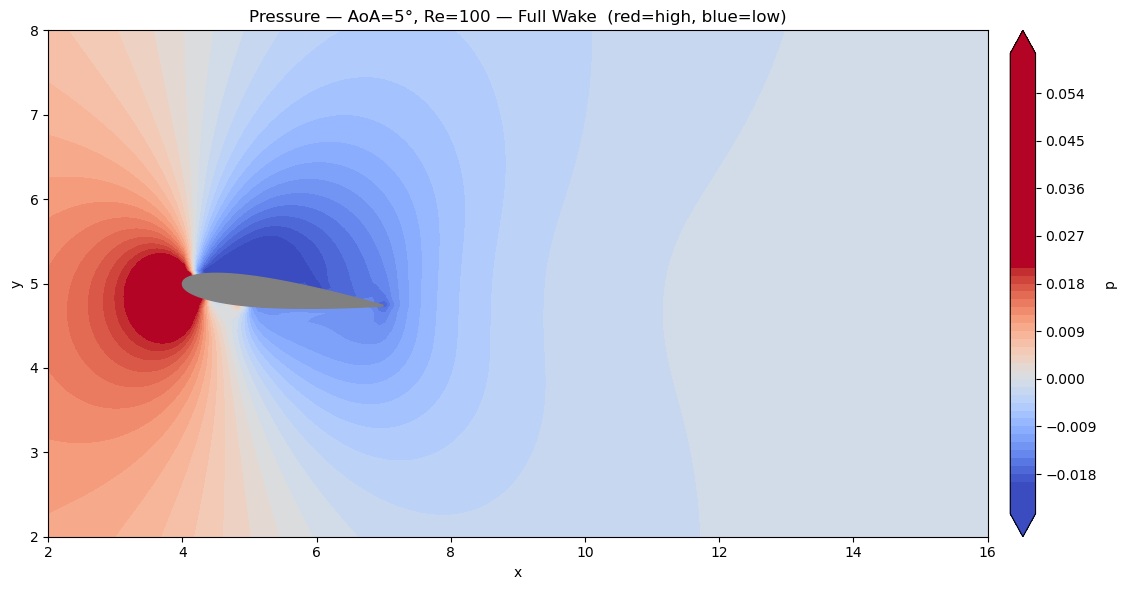

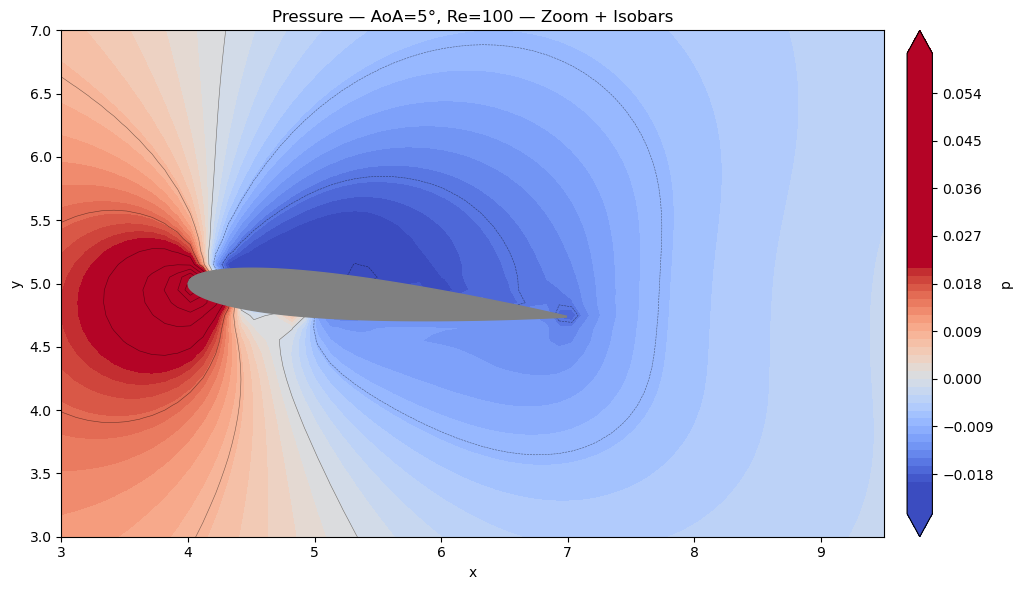

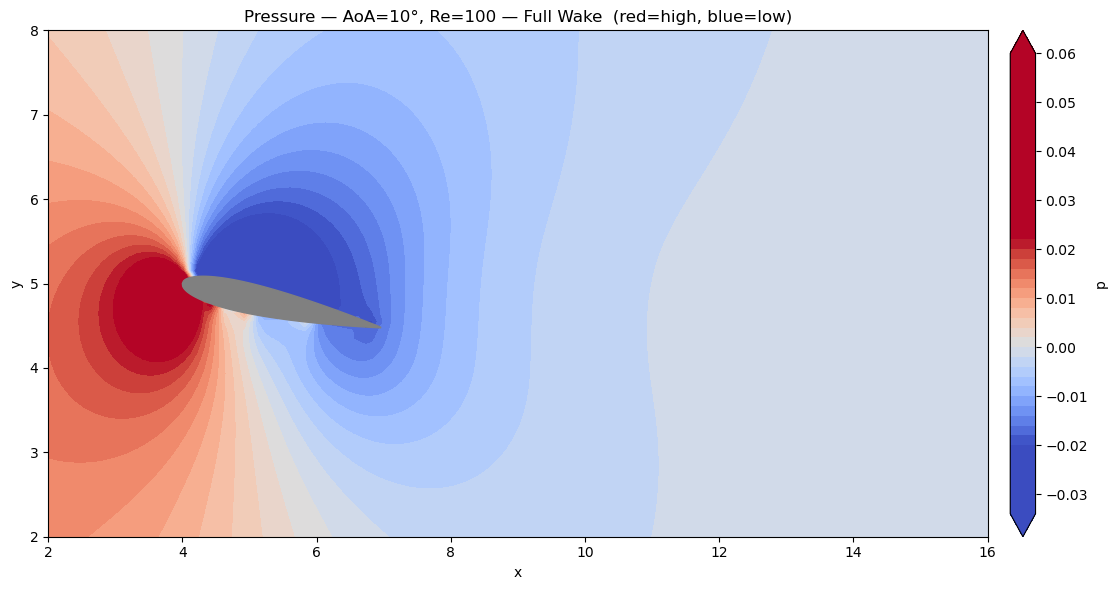

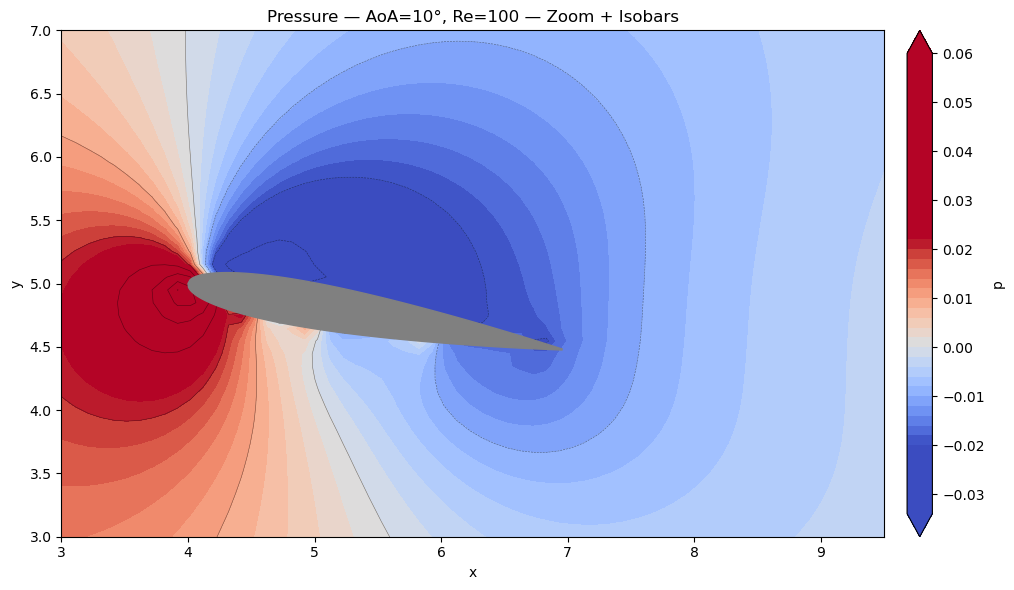

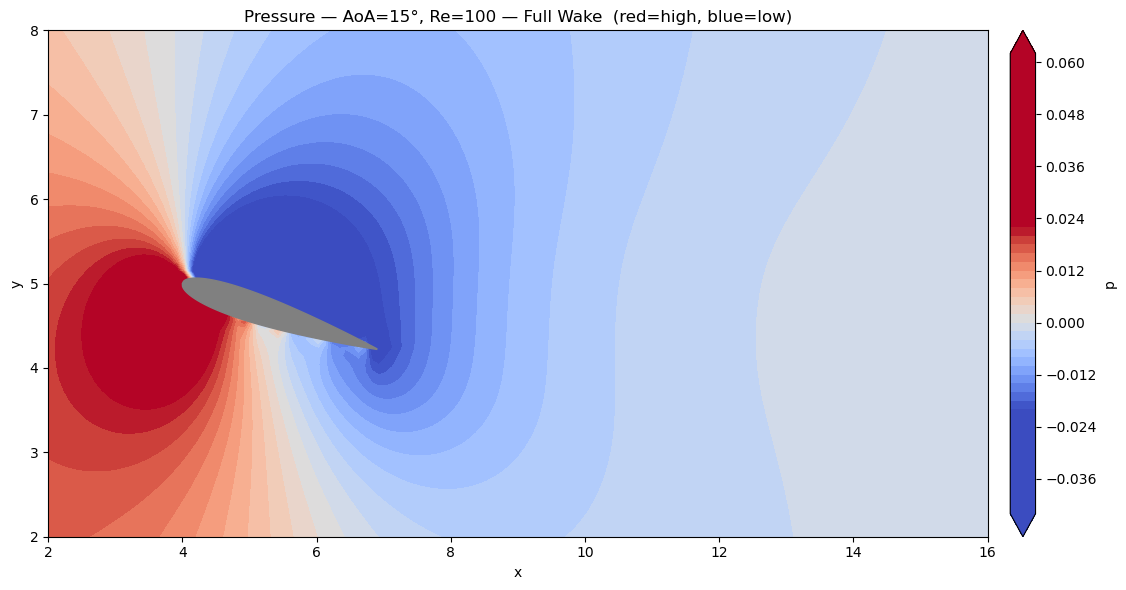

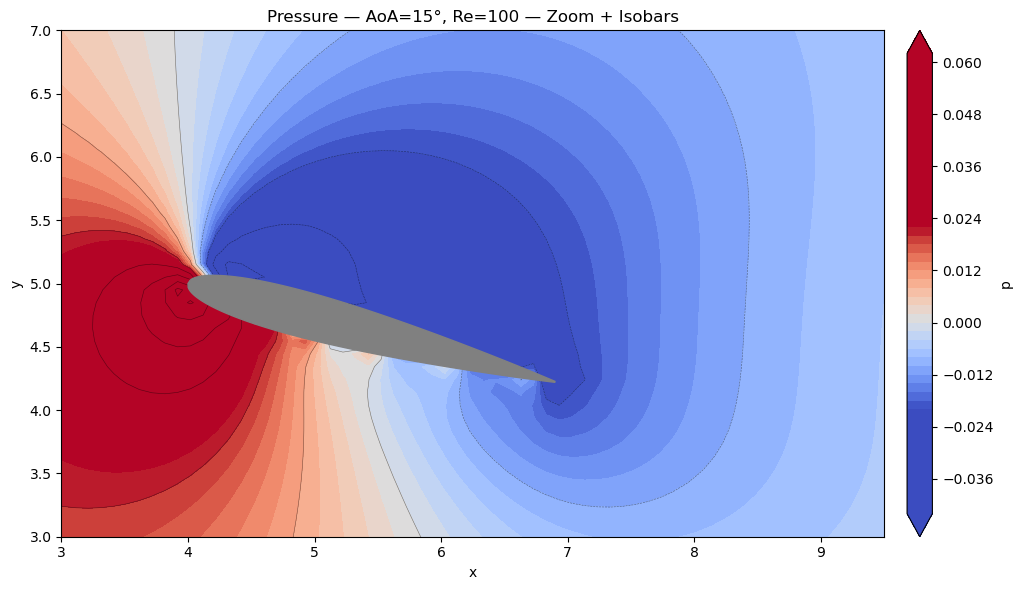

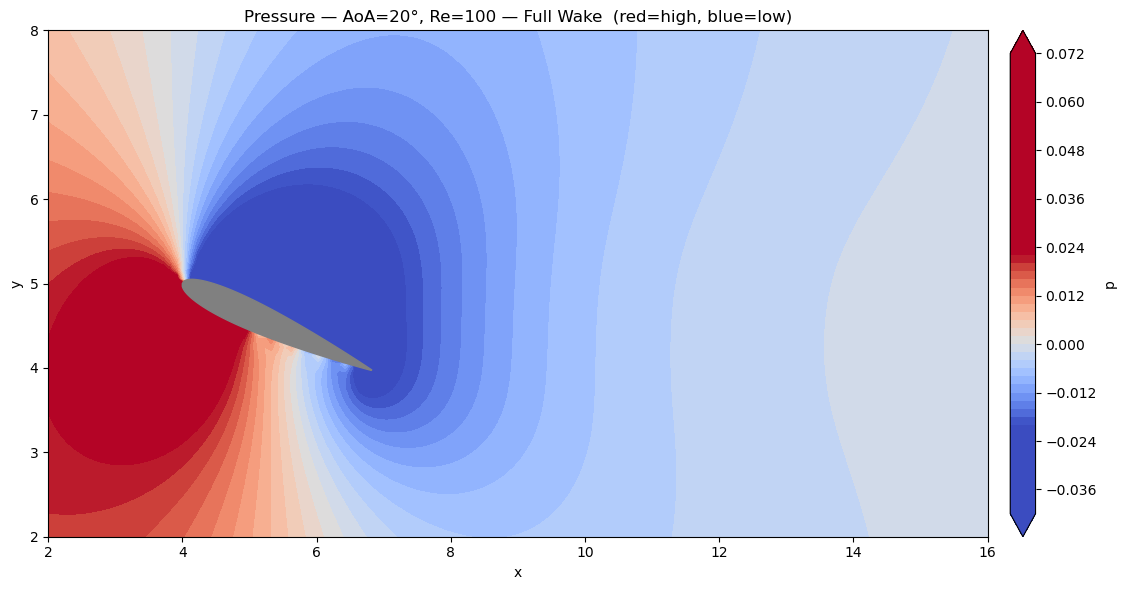

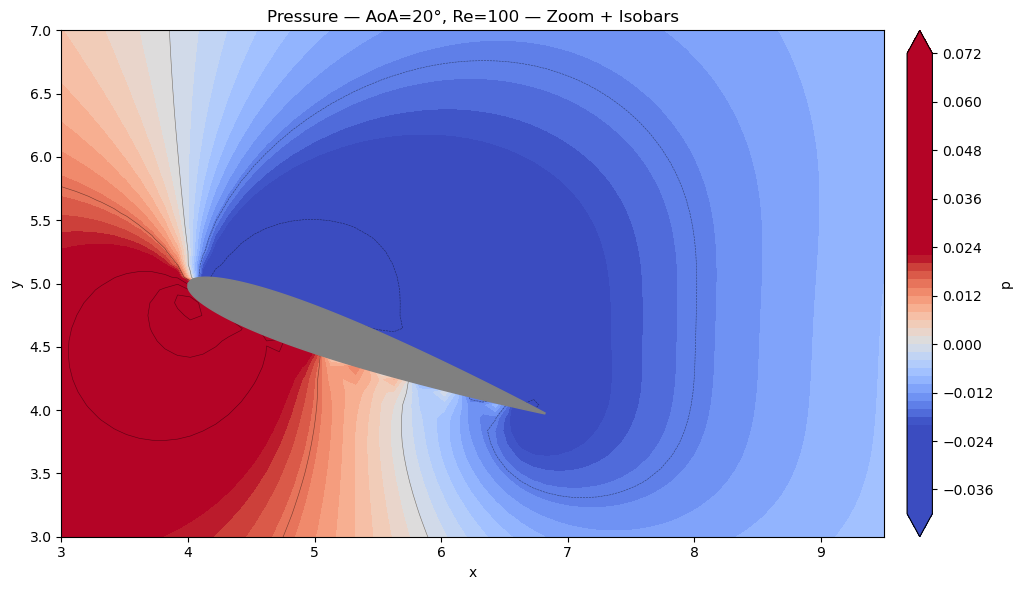

In [45]:
# ── Pressure ──────────────────────────────────────────────────────────────────
ZOOM_X = (3.0, 9.5)
ZOOM_Y = (3.0, 7.0)

p_plot = p_cpu_f.copy()
pmin_g = np.percentile(p_plot, 1)
pmax_g = np.percentile(p_plot, 99)
kw_p   = dict(levels=60, cmap='coolwarm', vmin=pmin_g, vmax=pmax_g, extend='both')

for i, aoa in enumerate(AoA_list):
    fig, ax = plt.subplots(figsize=(12, 6))
    im = ax.contourf(X_cpu, Y_cpu, p_plot[i], **kw_p)
    ax.add_patch(airfoil_patch(aoa_deg=aoa))
    ax.set_xlim(2, 16); ax.set_ylim(2, 8)
    ax.set_xlabel('x'); ax.set_ylabel('y')
    ax.set_title(f'Pressure — AoA={aoa}°, Re=100 — Full Wake  (red=high, blue=low)')
    fig.colorbar(im, ax=ax, label='p', pad=0.02)
    plt.tight_layout(); plt.show()

    fig, ax = plt.subplots(figsize=(12, 6))
    im = ax.contourf(X_cpu, Y_cpu, p_plot[i], **kw_p)
    ax.contour(X_cpu, Y_cpu, p_plot[i], levels=10,
               colors='k', linewidths=0.4, alpha=0.5)
    ax.add_patch(airfoil_patch(aoa_deg=aoa))
    ax.set_xlim(*ZOOM_X); ax.set_ylim(*ZOOM_Y)
    ax.set_aspect('equal')
    ax.set_xlabel('x'); ax.set_ylabel('y')
    ax.set_title(f'Pressure — AoA={aoa}°, Re=100 — Zoom + Isobars')
    fig.colorbar(im, ax=ax, label='p', pad=0.02)
    plt.tight_layout(); plt.show()

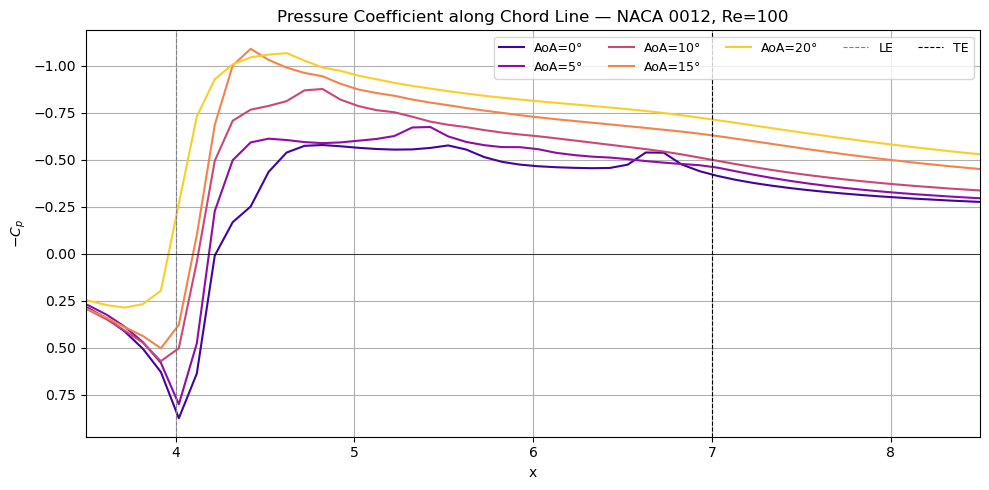

In [46]:
# ── Pressure coefficient (Cp) along the chord line ────────────────────────────
# Extract p at y = y_c (mid-row) along x, then compute Cp = (p - p_inf) / q
mid   = Ny // 2
q_ref = 0.5 * 1.0 * U_inf**2

# x-range covering the chord only
chord_mask = (x_cpu >= x_le) & (x_cpu <= x_le + C)
x_chord    = x_cpu[chord_mask]

plt.figure(figsize=(10, 5))
for i, aoa in enumerate(AoA_list):
    p_inf = p_cpu_f[i, mid, 0]    # upstream reference pressure
    Cp = (p_cpu_f[i, mid, :] - p_inf) / q_ref
    plt.plot(x_cpu, Cp, color=colors[i], label=f'AoA={aoa}°', lw=1.5)

plt.axvline(x_le,     color='gray',  ls='--', lw=0.8, label='LE')
plt.axvline(x_le + C, color='black', ls='--', lw=0.8, label='TE')
plt.axhline(0, color='k', lw=0.5)
plt.xlim(x_le - 0.5, x_le + C + 1.5)
plt.gca().invert_yaxis()   # convention: -Cp upward
plt.xlabel('x'); plt.ylabel('$-C_p$')
plt.title('Pressure Coefficient along Chord Line — NACA 0012, Re=100')
plt.legend(ncol=5, fontsize=9); plt.grid(True)
plt.tight_layout(); plt.show()

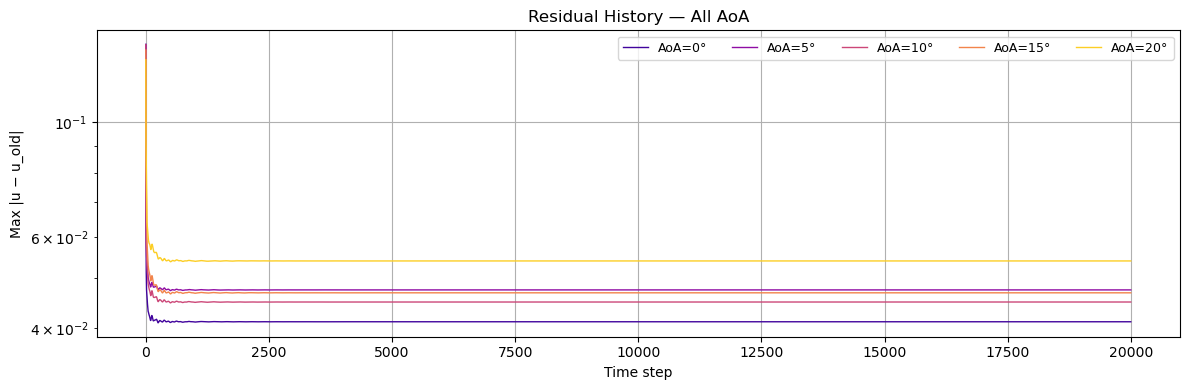

In [47]:
# ── Residual history (convergence check) ─────────────────────────────────────
plt.figure(figsize=(12, 4))
for i, aoa in enumerate(AoA_list):
    plt.semilogy(res_cpu[i], color=colors[i], label=f'AoA={aoa}°', lw=1)
plt.xlabel('Time step'); plt.ylabel('Max |u − u_old|')
plt.title('Residual History — All AoA')
plt.legend(ncol=5, fontsize=9); plt.grid(True)
plt.tight_layout(); plt.show()

In [48]:
# ── Performance summary ───────────────────────────────────────────────────────
print(f"Backend      : {backend_name}")
print(f"Total time   : {elapsed_total:.1f} s")
print(f"Steps/second : {nt/elapsed_total:.0f}")
print(f"AoA values   : {n_aoa}  (all ran simultaneously)")
print(f"Effective throughput: {n_aoa*nt/elapsed_total:.0f} AoA-steps/s")
print()
print("Final converged coefficients (mean over last 2000 steps):")
print(f"{'AoA':>5}  {'Cl':>8}  {'Cd':>8}  {'L/D':>8}")
print("-" * 35)
for i, aoa in enumerate(AoA_list):
    print(f"{aoa:>5}  {Cl_mean[i]:>8.4f}  {Cd_mean[i]:>8.4f}  {LoD[i]:>8.3f}")

Backend      : Apple M4 GPU (MPS)
Total time   : 254.6 s
Steps/second : 79
AoA values   : 5  (all ran simultaneously)
Effective throughput: 393 AoA-steps/s

Final converged coefficients (mean over last 2000 steps):
  AoA        Cl        Cd       L/D
-----------------------------------
    0   -0.0000    0.4044    -0.000
    5    0.2097    0.4228     0.496
   10    0.3597    0.4610     0.780
   15    0.5306    0.5503     0.964
   20    0.6536    0.6155     1.062


Generating images...


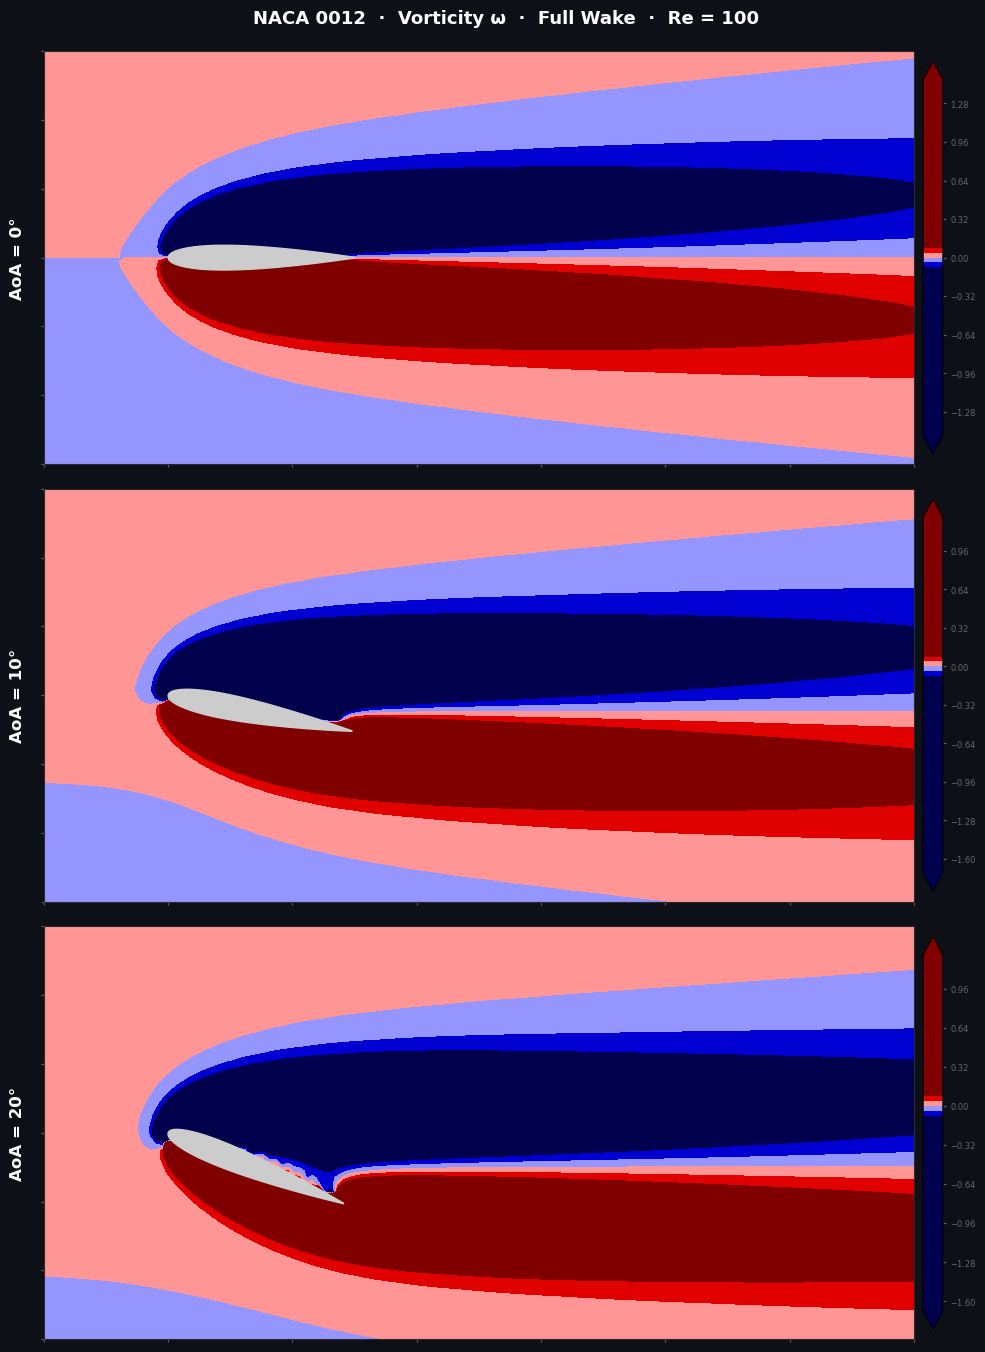

  Saved → linkedin_plots/01_vorticity_full.png


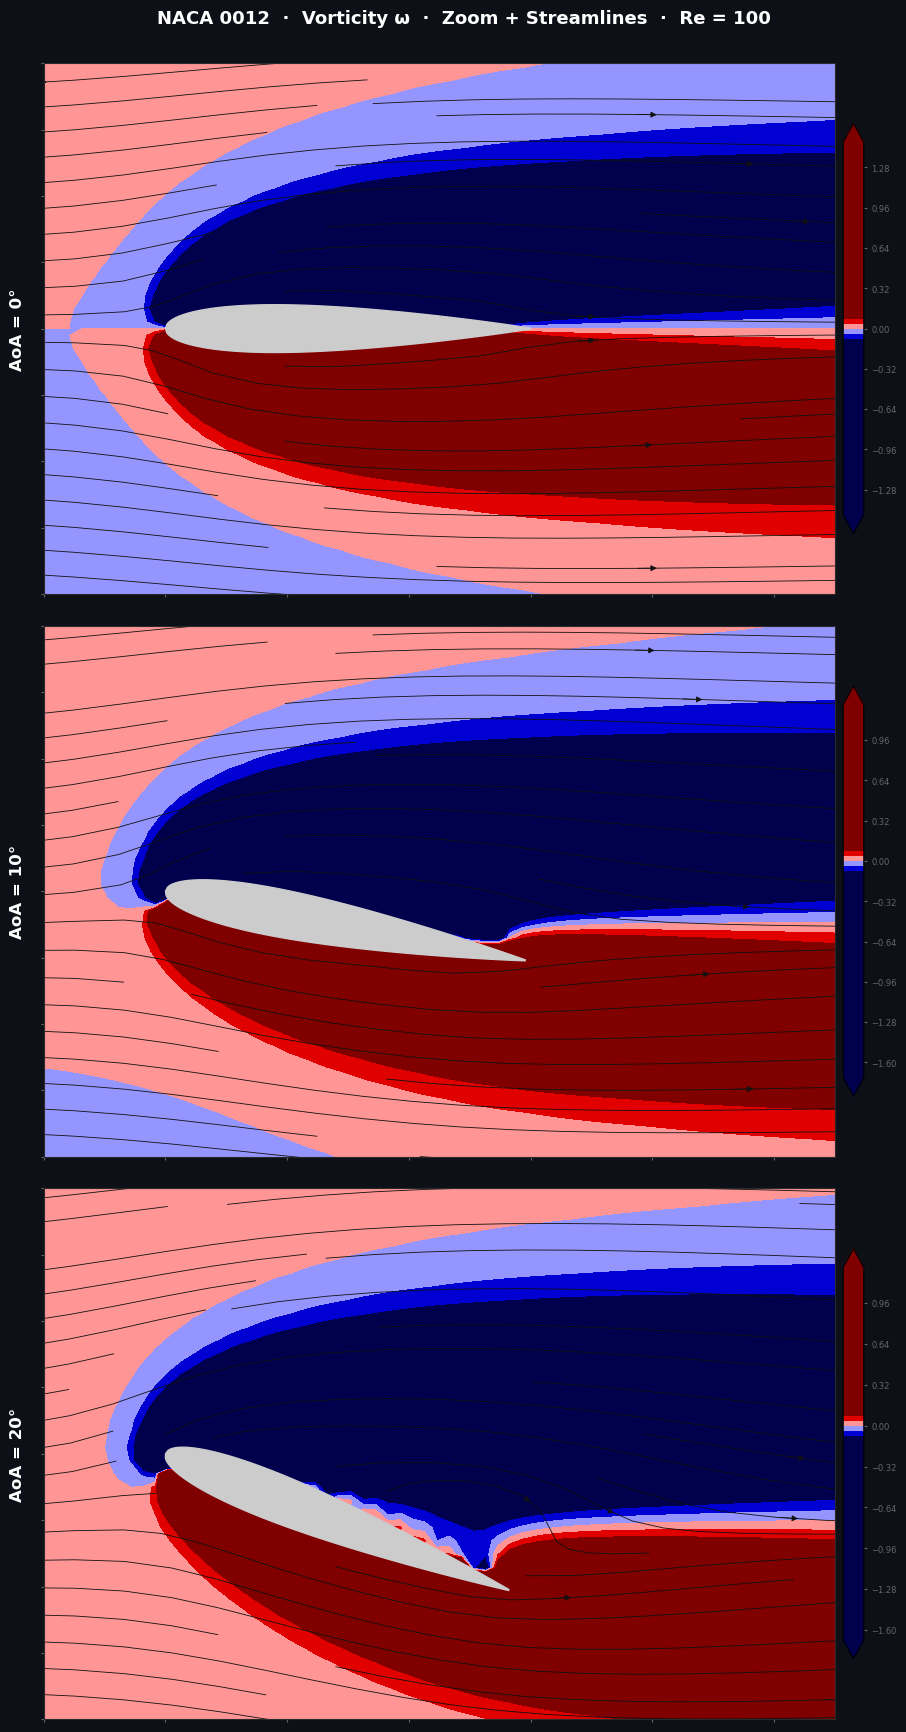

  Saved → linkedin_plots/02_vorticity_zoom_streamlines.png


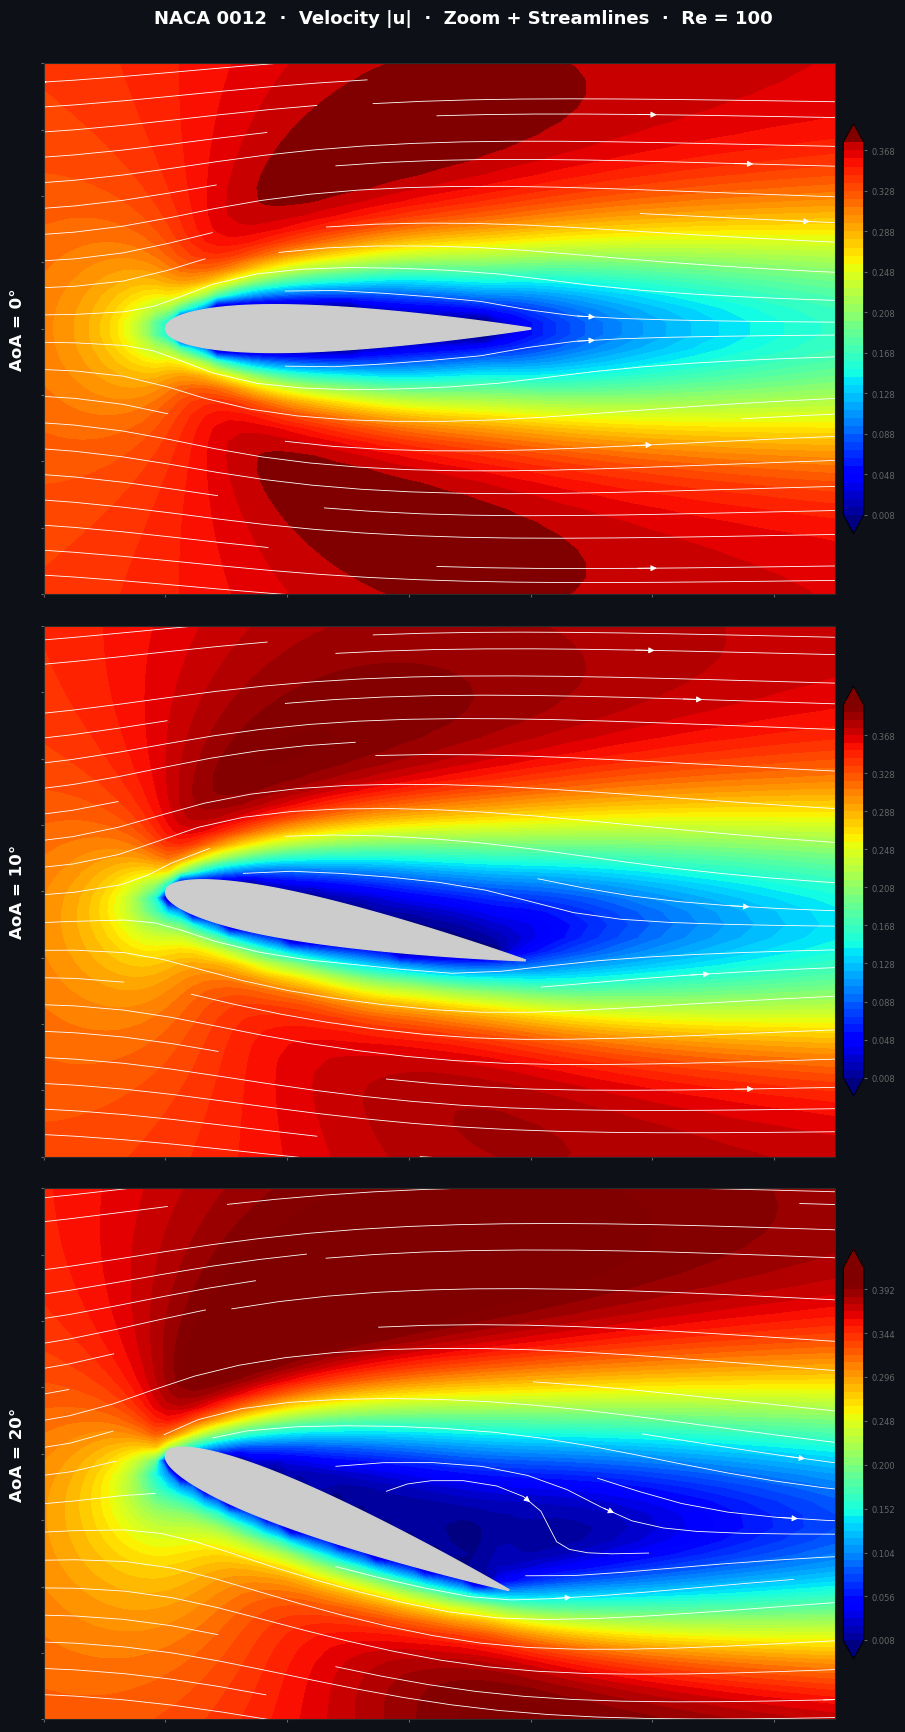

  Saved → linkedin_plots/03_velocity_zoom_streamlines.png


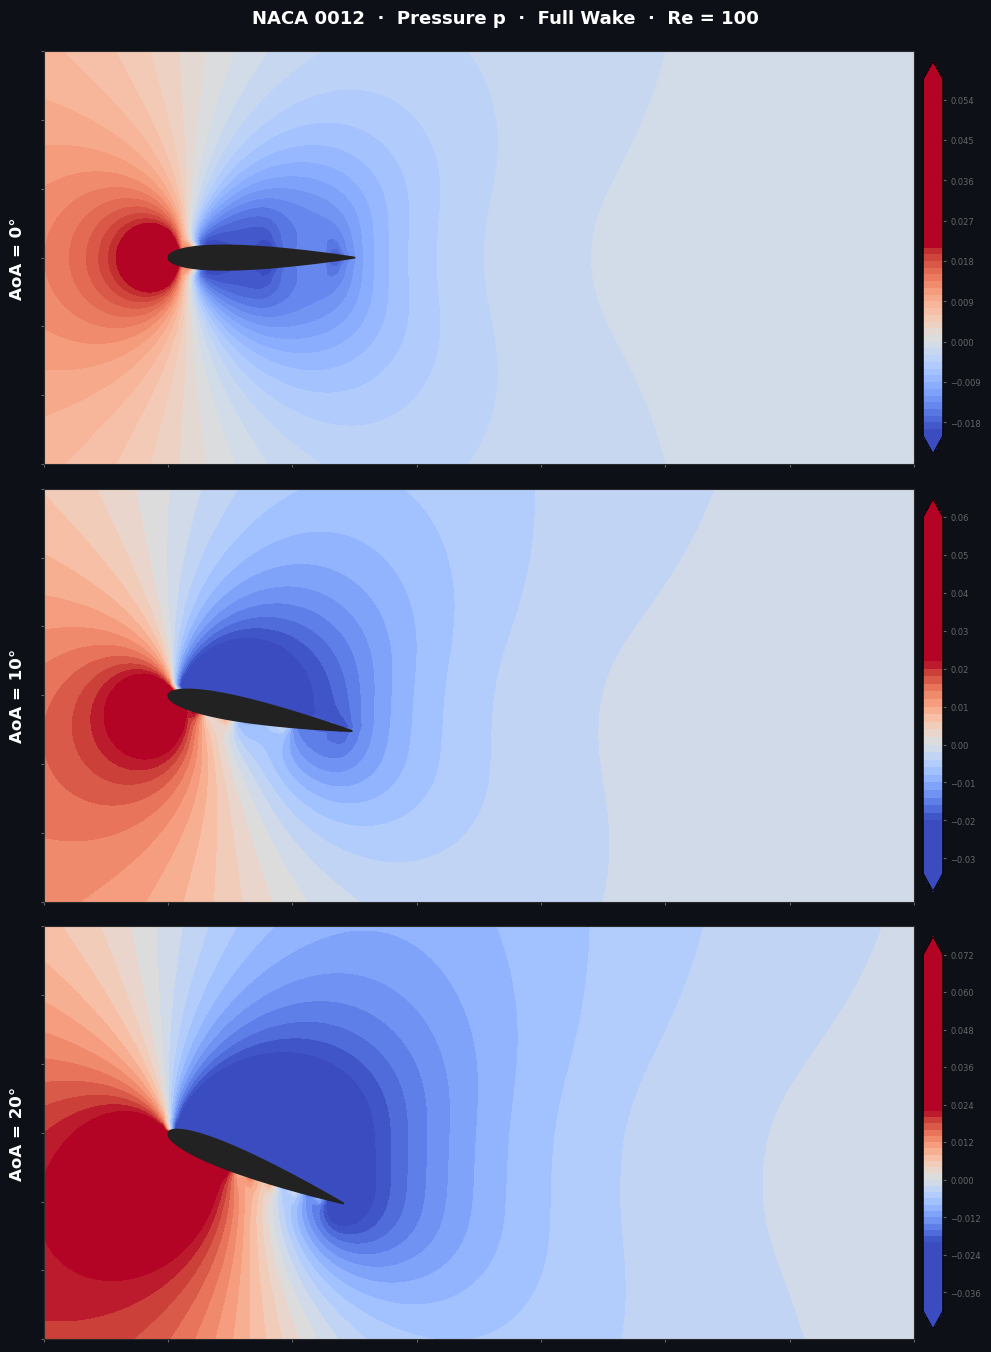

  Saved → linkedin_plots/04_pressure_full.png


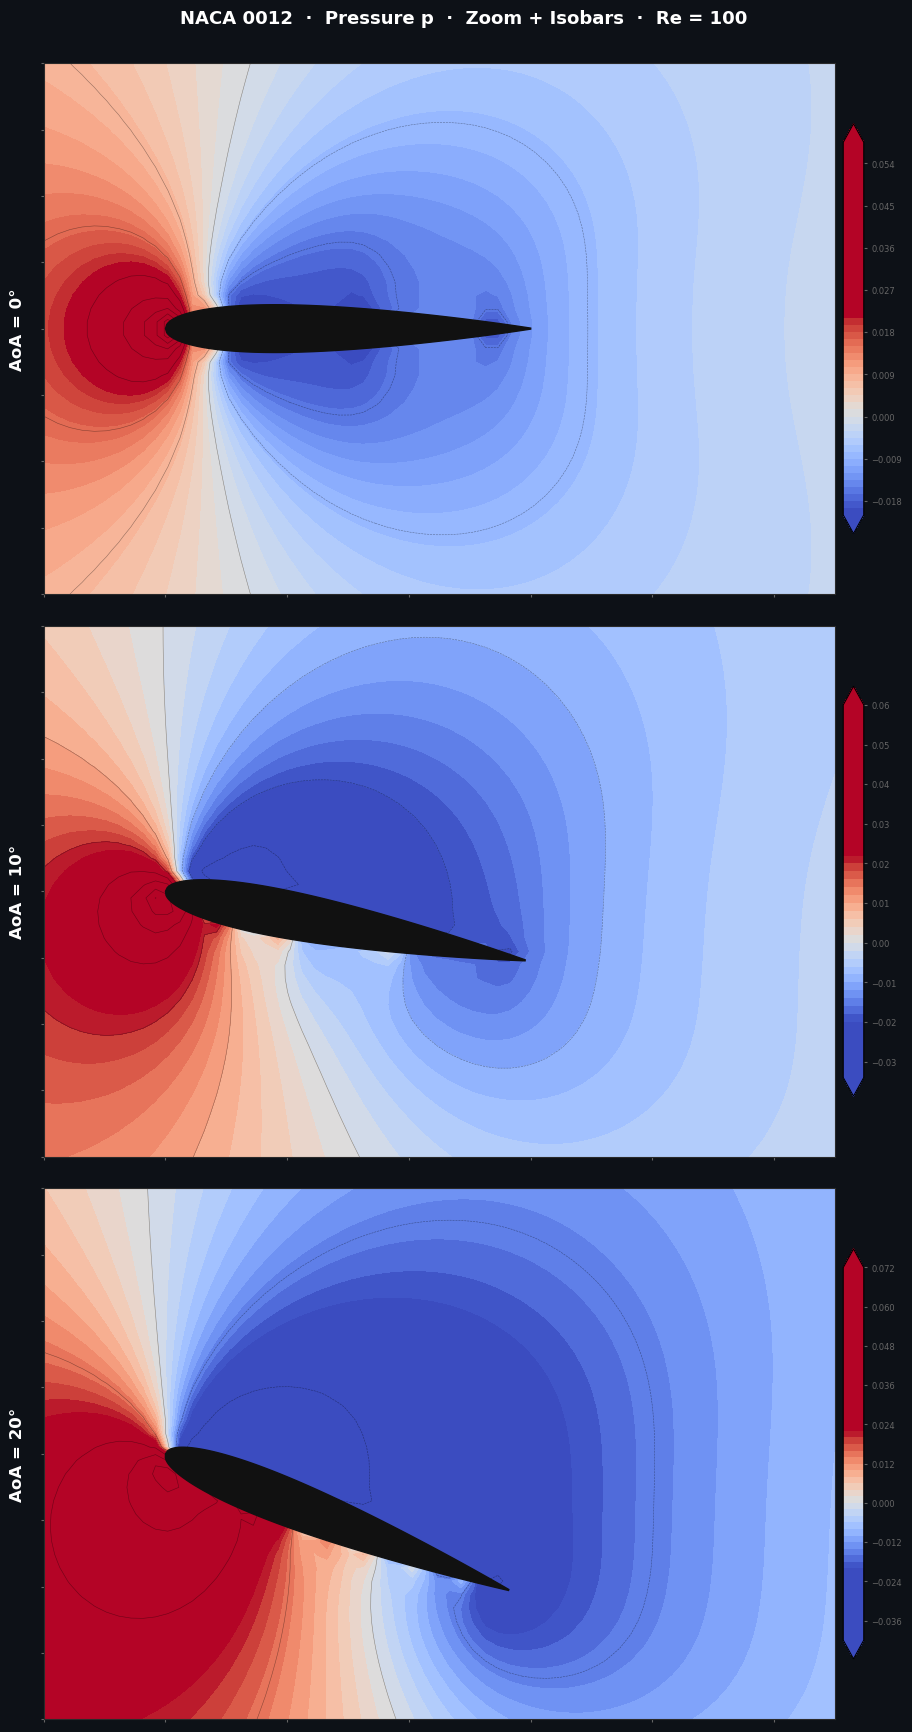

  Saved → linkedin_plots/05_pressure_zoom_isobars.png


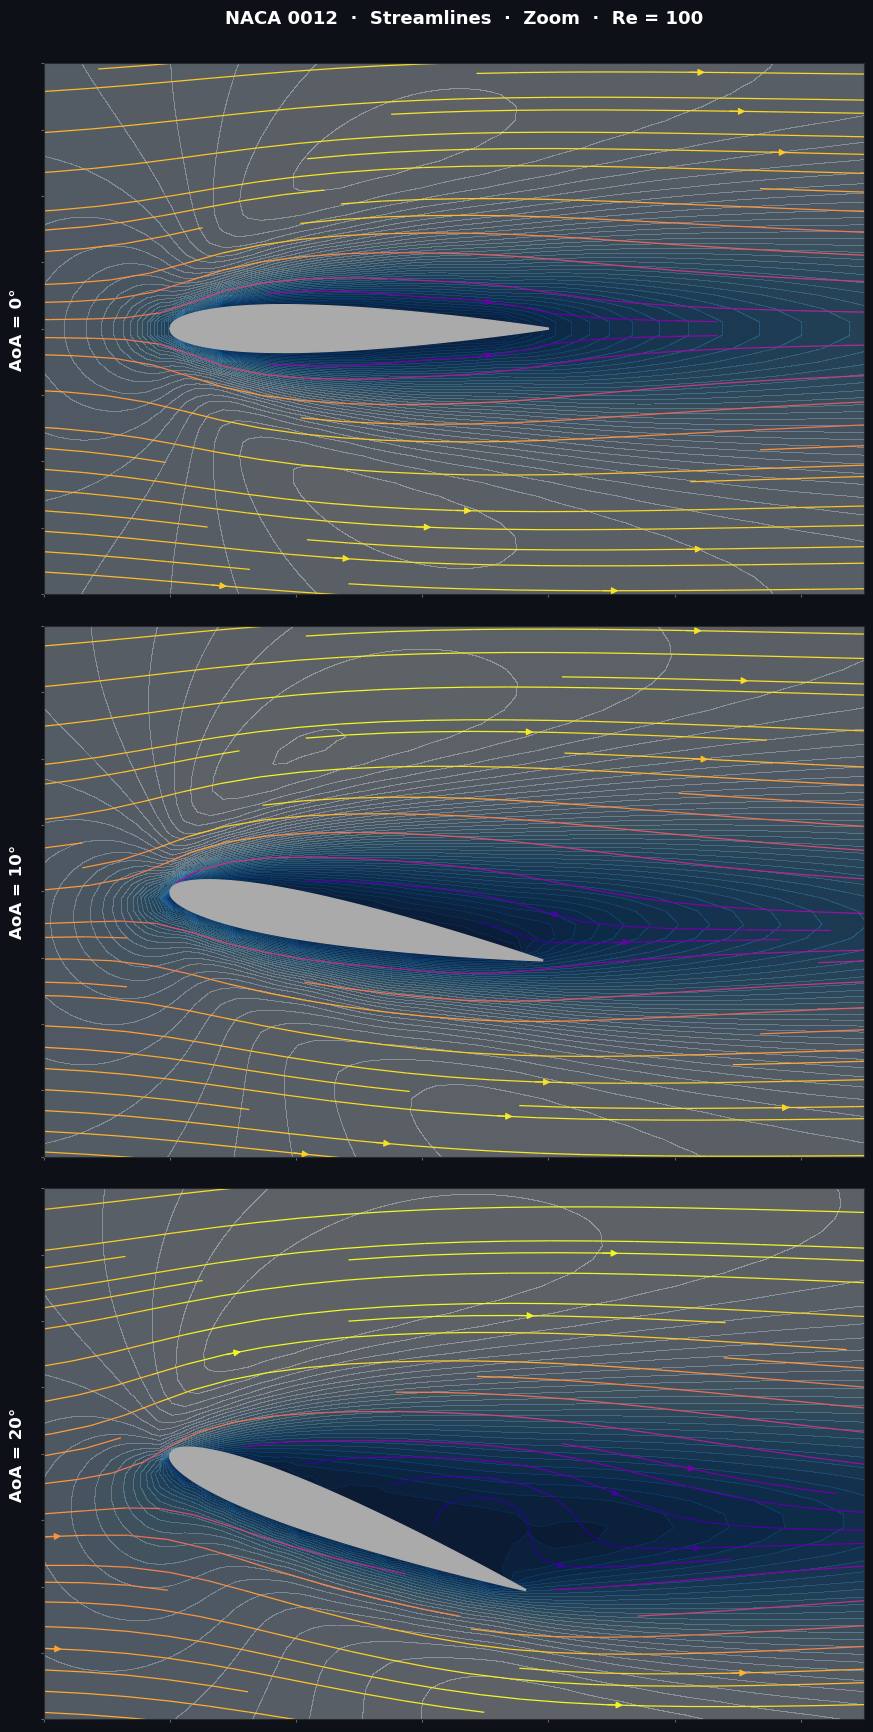

  Saved → linkedin_plots/06_streamlines_zoom_dark.png

All 6 images saved in  linkedin_plots/


In [53]:
# ══════════════════════════════════════════════════════════════════════════════
# LinkedIn Post Images — NACA 0012 AoA Sweep
#
# Produces 6 separate PNG files, each = 3 vertical subplots (AoA 0°/10°/20°):
#   01_vorticity_full.png
#   02_vorticity_zoom_streamlines.png
#   03_velocity_zoom_streamlines.png
#   04_pressure_full.png
#   05_pressure_zoom_isobars.png
#   06_streamlines_zoom_dark.png
# ══════════════════════════════════════════════════════════════════════════════
import os

PLOT_AOA = [0, 10, 20]
aoa_idx  = {a: AoA_list.index(a) for a in PLOT_AOA}
ZX = (3.0, 9.5)
ZY = (3.0, 7.0)
BG, FG, TICK = '#0d1117', 'white', '#666666'

# ── Precompute ────────────────────────────────────────────────────────────────
omega_dict = {}
for aoa in PLOT_AOA:
    k = aoa_idx[aoa]
    omega_dict[aoa] = ((v_cpu_f[k, 1:-1, 2:] - v_cpu_f[k, 1:-1, :-2]) / (2*dx)
                      -(u_cpu_f[k, 2:, 1:-1] - u_cpu_f[k, :-2, 1:-1]) / (2*dy))

vlim   = max(np.percentile(np.abs(omega_dict[a]), 85) for a in PLOT_AOA)
speed  = np.sqrt(u_cpu_f**2 + v_cpu_f**2)
vmax_s = np.percentile(speed, 99)
pmin_g = np.percentile(p_cpu_f, 1)
pmax_g = np.percentile(p_cpu_f, 99)
Xin    = X_cpu[1:-1, 1:-1]
Yin    = Y_cpu[1:-1, 1:-1]

os.makedirs('linkedin_plots', exist_ok=True)

# ── Helpers ───────────────────────────────────────────────────────────────────
def new_fig(title, figsize=(10, 18)):
    fig, axes = plt.subplots(3, 1, figsize=figsize, facecolor=BG)
    fig.subplots_adjust(hspace=0.06, left=0.08, right=0.90, top=0.94, bottom=0.02)
    fig.suptitle(title, color=FG, fontsize=13, fontweight='bold', y=0.97)
    return fig, axes

def style(ax, aoa, zoom=True):
    if zoom:
        ax.set_xlim(*ZX); ax.set_ylim(*ZY)
    else:
        ax.set_xlim(2, 16); ax.set_ylim(2, 8)
    ax.set_facecolor(BG)
    ax.tick_params(colors=TICK, labelsize=7, length=2)
    for sp in ax.spines.values(): sp.set_edgecolor('#2a2a2a')
    ax.set_xticklabels([]); ax.set_yticklabels([])
    ax.set_ylabel(f'AoA = {aoa}°', color=FG, fontsize=12,
                  fontweight='bold', labelpad=8)

def add_cb(fig, im, ax):
    cb = fig.colorbar(im, ax=ax, fraction=0.025, pad=0.01, shrink=0.95)
    cb.ax.tick_params(colors=TICK, labelsize=6, length=2)

def save(fig, fname):
    fig.savefig(f'linkedin_plots/{fname}', dpi=200, bbox_inches='tight',
                facecolor=BG, edgecolor='none')
    plt.show()
    print(f"  Saved → linkedin_plots/{fname}")

# ═══════════════════════════════════════════════════════════════════════════════
# Image 1 — Vorticity · Full Wake
# ═══════════════════════════════════════════════════════════════════════════════
print("Generating images...")
fig, axes = new_fig('NACA 0012  ·  Vorticity ω  ·  Full Wake  ·  Re = 100',
                    figsize=(11, 14))
for row, aoa in enumerate(PLOT_AOA):
    ax = axes[row]
    im = ax.contourf(Xin, Yin, omega_dict[aoa], levels=80,
                     cmap='seismic', vmin=-vlim, vmax=vlim, extend='both')
    ax.add_patch(airfoil_patch(aoa_deg=aoa, color='#cccccc'))
    add_cb(fig, im, ax)
    style(ax, aoa, zoom=False)
save(fig, '01_vorticity_full.png')

# ═══════════════════════════════════════════════════════════════════════════════
# Image 2 — Vorticity · Zoom + Streamlines
# ═══════════════════════════════════════════════════════════════════════════════
fig, axes = new_fig('NACA 0012  ·  Vorticity ω  ·  Zoom + Streamlines  ·  Re = 100')
for row, aoa in enumerate(PLOT_AOA):
    k  = aoa_idx[aoa]
    af = airfoil_masks_cpu[k]
    u_p = u_cpu_f[k].copy(); u_p[af] = np.nan
    v_p = v_cpu_f[k].copy(); v_p[af] = np.nan
    ax = axes[row]
    im = ax.contourf(Xin, Yin, omega_dict[aoa], levels=80,
                     cmap='seismic', vmin=-vlim, vmax=vlim, extend='both')
    ax.streamplot(X_cpu, Y_cpu, u_p, v_p,
                  density=1.8, color='#111111', linewidth=0.6, arrowsize=0.9)
    ax.add_patch(airfoil_patch(aoa_deg=aoa, color='#cccccc'))
    add_cb(fig, im, ax)
    style(ax, aoa)
save(fig, '02_vorticity_zoom_streamlines.png')

# ═══════════════════════════════════════════════════════════════════════════════
# Image 3 — Velocity · Zoom + Streamlines
# ═══════════════════════════════════════════════════════════════════════════════
fig, axes = new_fig('NACA 0012  ·  Velocity |u|  ·  Zoom + Streamlines  ·  Re = 100')
for row, aoa in enumerate(PLOT_AOA):
    k  = aoa_idx[aoa]
    af = airfoil_masks_cpu[k]
    u_p = u_cpu_f[k].copy(); u_p[af] = np.nan
    v_p = v_cpu_f[k].copy(); v_p[af] = np.nan
    ax = axes[row]
    im = ax.contourf(X_cpu, Y_cpu, speed[k], levels=60,
                     cmap='jet', vmin=0, vmax=vmax_s, extend='both')
    ax.streamplot(X_cpu, Y_cpu, u_p, v_p,
                  density=1.8, color='white', linewidth=0.6, arrowsize=0.9)
    ax.add_patch(airfoil_patch(aoa_deg=aoa, color='#cccccc'))
    add_cb(fig, im, ax)
    style(ax, aoa)
save(fig, '03_velocity_zoom_streamlines.png')

# ═══════════════════════════════════════════════════════════════════════════════
# Image 4 — Pressure · Full Wake
# ═══════════════════════════════════════════════════════════════════════════════
fig, axes = new_fig('NACA 0012  ·  Pressure p  ·  Full Wake  ·  Re = 100',
                    figsize=(11, 14))
for row, aoa in enumerate(PLOT_AOA):
    k  = aoa_idx[aoa]
    ax = axes[row]
    im = ax.contourf(X_cpu, Y_cpu, p_cpu_f[k], levels=60,
                     cmap='coolwarm', vmin=pmin_g, vmax=pmax_g, extend='both')
    ax.add_patch(airfoil_patch(aoa_deg=aoa, color='#222222'))
    add_cb(fig, im, ax)
    style(ax, aoa, zoom=False)
save(fig, '04_pressure_full.png')

# ═══════════════════════════════════════════════════════════════════════════════
# Image 5 — Pressure · Zoom + Isobars
# ═══════════════════════════════════════════════════════════════════════════════
fig, axes = new_fig('NACA 0012  ·  Pressure p  ·  Zoom + Isobars  ·  Re = 100')
for row, aoa in enumerate(PLOT_AOA):
    k  = aoa_idx[aoa]
    ax = axes[row]
    im = ax.contourf(X_cpu, Y_cpu, p_cpu_f[k], levels=60,
                     cmap='coolwarm', vmin=pmin_g, vmax=pmax_g, extend='both')
    ax.contour(X_cpu, Y_cpu, p_cpu_f[k], levels=10,
               colors='k', linewidths=0.4, alpha=0.4)
    ax.add_patch(airfoil_patch(aoa_deg=aoa, color='#111111'))
    add_cb(fig, im, ax)
    style(ax, aoa)
save(fig, '05_pressure_zoom_isobars.png')

# ═══════════════════════════════════════════════════════════════════════════════
# Image 6 — Streamlines · Zoom · Dark Plasma
# ═══════════════════════════════════════════════════════════════════════════════
fig, axes = new_fig('NACA 0012  ·  Streamlines  ·  Zoom  ·  Re = 100')
for row, aoa in enumerate(PLOT_AOA):
    k  = aoa_idx[aoa]
    af = airfoil_masks_cpu[k]
    u_p = u_cpu_f[k].copy(); u_p[af] = np.nan
    v_p = v_cpu_f[k].copy(); v_p[af] = np.nan
    ax = axes[row]
    ax.set_facecolor('#090e15')
    ax.contourf(X_cpu, Y_cpu, speed[k], levels=40,
                cmap='Blues_r', vmin=0, vmax=vmax_s, alpha=0.35, extend='both')
    ax.streamplot(X_cpu, Y_cpu, u_p, v_p,
                  density=2.2, linewidth=0.9, arrowsize=1.0,
                  color=speed[k], cmap='plasma',
                  norm=plt.Normalize(0, vmax_s))
    ax.add_patch(airfoil_patch(aoa_deg=aoa, color='#aaaaaa'))
    style(ax, aoa)
save(fig, '06_streamlines_zoom_dark.png')

print("\nAll 6 images saved in  linkedin_plots/")

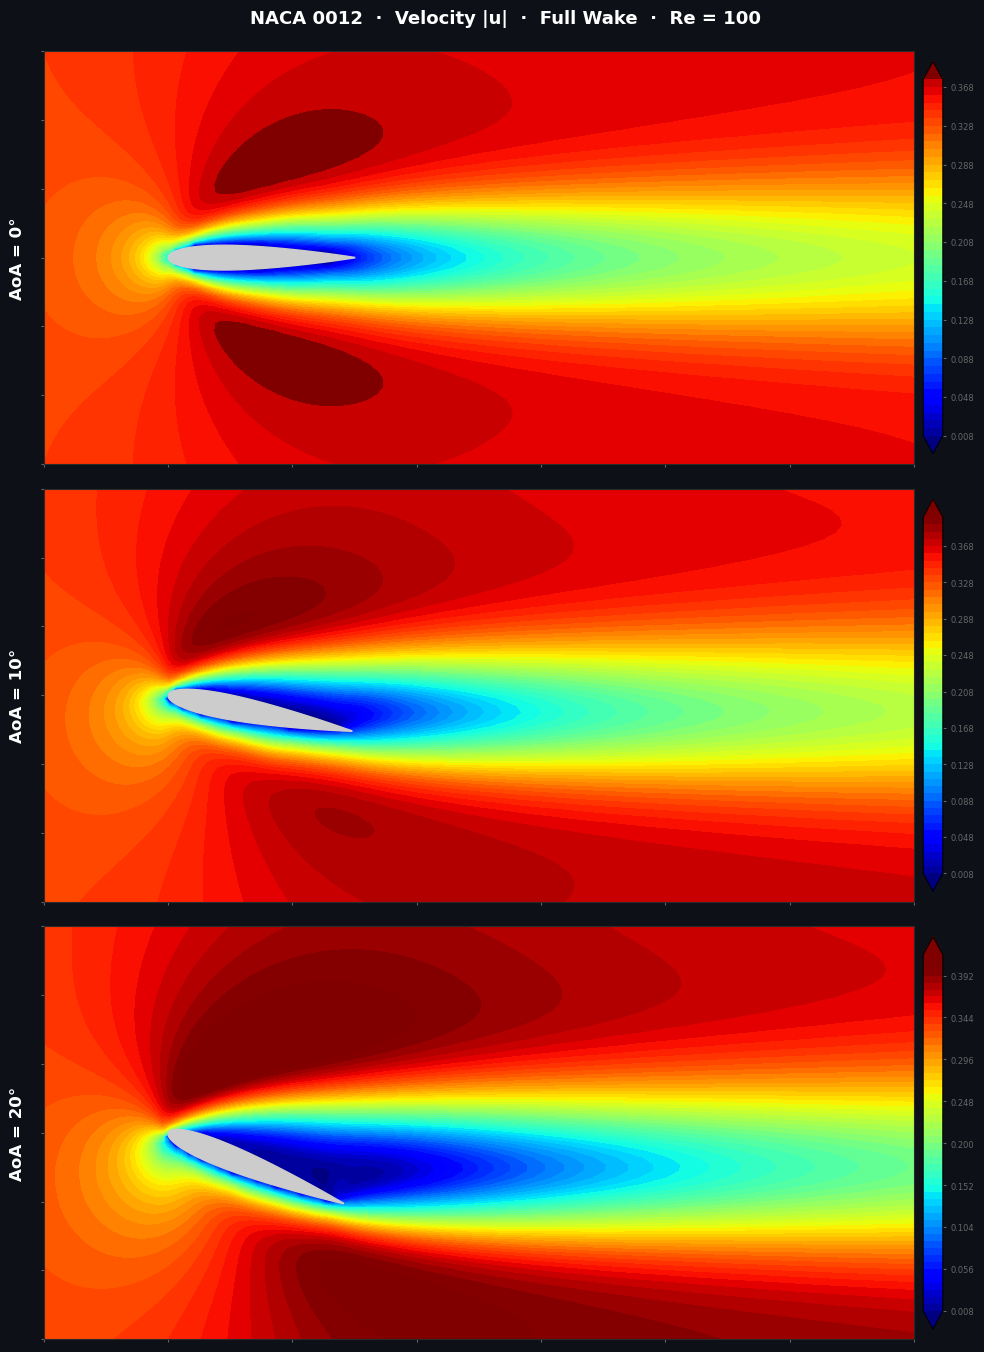

  Saved → linkedin_plots/03b_velocity_full.png


In [54]:
# ═══════════════════════════════════════════════════════════════════════════════
# Image 3b — Velocity · Full Wake
# ═══════════════════════════════════════════════════════════════════════════════

speed  = np.sqrt(u_cpu_f**2 + v_cpu_f**2)
vmax_s = np.percentile(speed, 99)

fig, axes = new_fig('NACA 0012  ·  Velocity |u|  ·  Full Wake  ·  Re = 100',
                    figsize=(11, 14))

for row, aoa in enumerate(PLOT_AOA):
    k  = aoa_idx[aoa]
    ax = axes[row]
    im = ax.contourf(X_cpu, Y_cpu, speed[k], levels=60,
                     cmap='jet', vmin=0, vmax=vmax_s, extend='both')
    ax.add_patch(airfoil_patch(aoa_deg=aoa, color='#cccccc'))
    add_cb(fig, im, ax)
    style(ax, aoa, zoom=False)

save(fig, '03b_velocity_full.png')

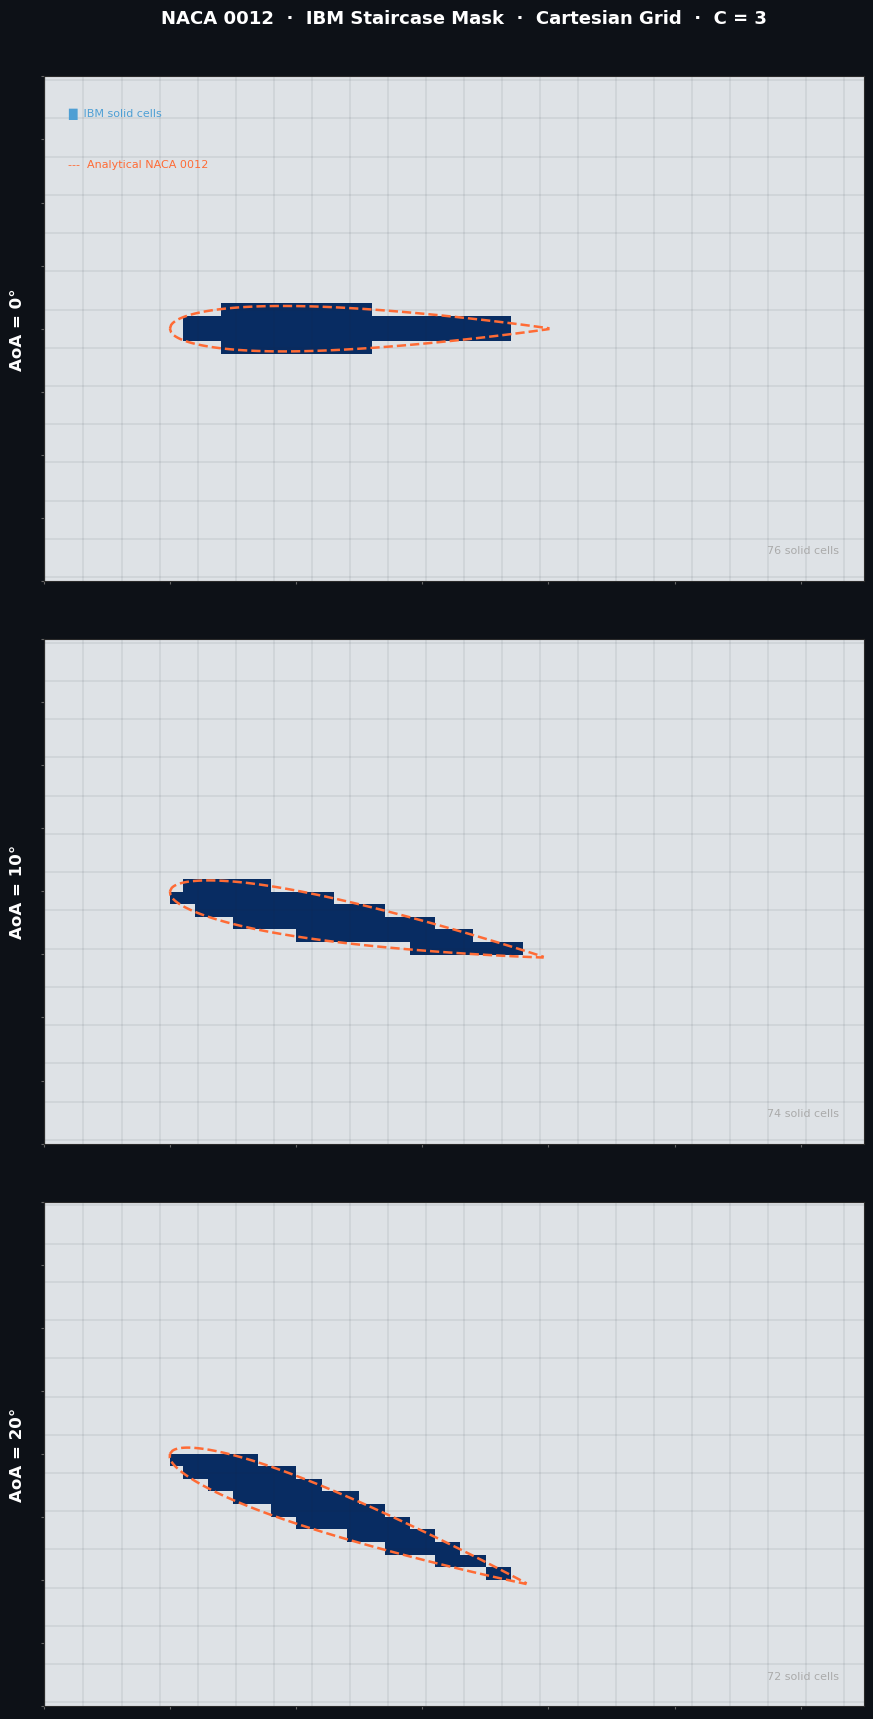

  Saved → linkedin_plots/07_ibm_mask_zoom.png
All 7 images saved in  linkedin_plots/


In [55]:
# ═══════════════════════════════════════════════════════════════════════════════
# Image 7 — IBM Airfoil Mask · Zoom
# Shows the Cartesian staircase representation of the NACA 0012 at each AoA,
# overlaid with the smooth analytical airfoil polygon for comparison.
# ═══════════════════════════════════════════════════════════════════════════════

fig, axes = new_fig('NACA 0012  ·  IBM Staircase Mask  ·  Cartesian Grid  ·  C = 3',
                    figsize=(10, 18))

for row, aoa in enumerate(PLOT_AOA):
    k  = aoa_idx[aoa]
    ax = axes[row]

    # Staircase IBM mask — show solid cells as filled squares
    mask_float = airfoil_masks_cpu[k].astype(float)
    ax.imshow(mask_float, origin='lower', cmap='Blues',
              extent=[0, Lx, 0, Ly], alpha=0.9, vmin=0, vmax=1,
              interpolation='nearest')

    # Grid lines to make individual cells visible
    for xg in x_cpu[::3]:
        ax.axvline(xg, color='#1a2a3a', lw=0.2, alpha=0.5)
    for yg in y_cpu[::3]:
        ax.axhline(yg, color='#1a2a3a', lw=0.2, alpha=0.5)

    # Smooth analytical airfoil outline for comparison
    patch = airfoil_patch(aoa_deg=aoa, color='none')
    patch.set_edgecolor('#ff6b35')
    patch.set_linewidth(1.8)
    patch.set_linestyle('--')
    patch.set_zorder(6)
    ax.add_patch(patch)

    # Cell count annotation
    n_cells = airfoil_masks_cpu[k].sum()
    ax.text(0.97, 0.05, f'{n_cells} solid cells',
            transform=ax.transAxes, color='#aaaaaa',
            fontsize=8, ha='right', va='bottom')

    style(ax, aoa)

# Legend annotation on top subplot
axes[0].text(0.03, 0.92, '█  IBM solid cells',
             transform=axes[0].transAxes, color='#4e9fd4', fontsize=8)
axes[0].text(0.03, 0.82, '---  Analytical NACA 0012',
             transform=axes[0].transAxes, color='#ff6b35', fontsize=8)

save(fig, '07_ibm_mask_zoom.png')
print("All 7 images saved in  linkedin_plots/")